# Введение в простые числа

Введение в вычислительную работу с простыми числами: организация накопительной библиотеки `crypto_math`, проверка простоты перебором делителей и анализ её сложности, решето Эратосфена и его оптимизация, вычислительное исследование распределения простых чисел, функции $\pi(x)$, асимптотического закона распределения простых чисел и промежутков между соседними простыми числами.

# 1. Создание накопительной библиотеки `crypto_math`

В Notebook 1 мы вывели, реализовали и протестировали базовые алгоритмы теории чисел. Начиная с Notebook 2 эти алгоритмы должны стать **переиспользуемым математическим инструментарием**.

Цель этого задания — организовать единую библиотеку `crypto_math`, которая будет использоваться во всех последующих ноутбуках курса и постепенно расширяться вместе с ним.

<div style="background-color: #23282d; padding: 20px; border-radius: 10px; border-left: 4px solid #007cba;">

### Создание накопительной библиотеки `crypto_math`

Создайте в корне курса единый устанавливаемый Python-пакет `crypto_math`.

Перенесите в него проверенные функции Notebook 1:

`random_exact_bits`, `divides`, `gcd`, `extended_gcd`, `solve_linear_diophantine`, `mod_inverse`, `solve_linear`, `mod_pow`, `crt`, `garner_crt`.

Библиотека должна:

1. находиться **в корне курса**, а не внутри каталога отдельного ноутбука;
2. устанавливаться в editable-режиме;
3. импортироваться из Notebook 2 и последующих ноутбуков без изменения `sys.path`;
4. иметь единый каталог тестов;
5. расширяться тематическими модулями только после того, как соответствующие алгоритмы выведены, реализованы и протестированы в курсе.

Задание выполняйте по нижеприведенным шагам.
</div>

## Шаг 1. Создайте общий каталог курса

Ноутбуки разных тем не должны содержать собственные копии `crypto_math`.

Создайте один корневой каталог курса, например:

```text
PKC_Course/
```

Рекомендуемая структура:

```text
PKC_Course/
│
├── crypto_math/
├── tests/
│
├── 1/
│   └── 01_2026.ipynb
│
├── 2/
│   └── 02_2026.ipynb
│
├── ...
└── pyproject.toml
```

Каталоги `1/`, `2/`, ... содержат последовательные ноутбуки курса.

Библиотека `crypto_math` располагается **на одном уровне с ними**.

Это даёт единственный актуальный экземпляр каждой функции. Если позднее будет исправлена реализация `mod_pow`, исправление автоматически относится ко всему курсу, а не к одной случайной копии библиотеки.

## Шаг 2. Создайте структуру библиотеки

В корне `PKC_Course` создайте каталог `crypto_math/` с пока пустыми файлами `number_theory.py` и `__init__.py`:

```text
crypto_math/
├── __init__.py
└── number_theory.py
```

## Шаг 3. Перенесите результаты Notebook 1

В файл

```text
crypto_math/number_theory.py
```

перенесите проверенные реализации:

```python
random_exact_bits
divides
gcd
extended_gcd
solve_linear_diophantine
mod_inverse
solve_linear
mod_pow
crt
garner_crt
```

<div style="border-left: 3px solid #666; padding-left: 18px; margin: 18px 0;">

<strong>Разделение ролей.</strong>

Notebook хранит вывод, доказательства, объяснения, эксперименты и benchmark.

`crypto_math` хранит проверенные переиспользуемые алгоритмы.

</div>

## Шаг 4. Наполнение `__init__.py`

Файл

```text
crypto_math/__init__.py
```

задаёт публичный интерфейс пакета на текущем этапе курса:

```python
from .number_theory import (
    random_exact_bits,
    divides,
    gcd,
    extended_gcd,
    solve_linear_diophantine,
    mod_inverse,
    solve_linear,
    mod_pow,
    crt,
    garner_crt,
)

__all__ = [
    "random_exact_bits",
    "divides",
    "gcd",
    "extended_gcd",
    "solve_linear_diophantine",
    "mod_inverse",
    "solve_linear",
    "mod_pow",
    "crt",
    "garner_crt",
]
```

После этого возможен импорт

```python
from crypto_math import gcd
```

Однако по мере роста курса предпочтительны явные тематические импорты:

```python
from crypto_math.number_theory import gcd, mod_inverse, mod_pow
```

Так по самому импорту видно, из какого математического слоя происходит используемый алгоритм.

## Шаг 5. Создайте `pyproject.toml`

Теперь у нас есть каталог `crypto_math` с Python-файлами, но сам по себе каталог ещё не является **установленным пакетом** для выбранного Python-окружения.

Чтобы `pip` понимал, что именно нужно установить, в корне `PKC_Course`, рядом с каталогами `crypto_math/`, `1/`, `2/` и `tests/`, создайте файл

```text
pyproject.toml
```

со следующим содержимым:

```toml
[build-system]
requires = ["setuptools>=68"]
build-backend = "setuptools.build_meta"

[project]
name = "crypto-math-course"
version = "0.1.0"
description = "Educational library for the asymmetric cryptography course"
requires-python = ">=3.10"
dependencies = []

[project.optional-dependencies]
test = [
    "pytest>=8",
    "hypothesis>=6",
]

[tool.pytest.ini_options]
testpaths = ["tests"]
```

`pyproject.toml` — это описание Python-проекта. В частности, из него инструменты установки узнают имя проекта, требуемую версию Python и дополнительные зависимости.

Здесь важно различать два имени:

- `crypto-math-course` — имя **проекта**, которое видит `pip`;
- `crypto_math` — имя **Python-пакета**, которое мы пишем в `import`.

Поэтому команда установки будет работать с проектом `crypto-math-course`, а в программе мы продолжим писать, например,

```python
from crypto_math.number_theory import gcd
```

<div style="border-left: 3px solid #666; padding-left: 18px; margin: 18px 0;">

<strong>Что мы сейчас сделали?</strong>

Мы не установили библиотеку. Мы только описали проект так, чтобы на следующем шаге `pip` смог корректно связать каталог `crypto_math/` с выбранным Python-окружением.

</div>

## Шаг 6. Установите библиотеку в Linux

Установка Python-пакета всегда происходит **в конкретное Python-окружение**. Это существенно: на одном компьютере могут одновременно существовать системный Python, виртуальное окружение, Conda/SageMath и отдельный Python, которым пользуется Jupyter.

Нам нужно установить `crypto_math` именно туда, откуда её будет импортировать Notebook 2.

### 6.1. Сначала узнайте Python текущего Jupyter kernel

В Notebook 2 выполните:

```python
import sys
print(sys.executable)
```

`sys.executable` показывает полный путь к интерпретатору Python, который сейчас выполняет код ноутбука.

Сохраните этот путь. Именно через этот Python мы будем запускать `pip`.

In [1]:
import sys
print(sys.executable)

/mnt/sage_disk/conda/miniforge3/envs/sage/bin/python


### 6.2. Перейдите в корень курса

Откройте терминал и перейдите в каталог, где находится `pyproject.toml`:

```bash
cd ~/PKC_Course
```

Проверьте, что вы действительно находитесь в корне проекта:

```bash
ls
```

### 6.3. Установите пакет тем же Python, который использует Jupyter

Если `sys.executable` показал, например,

```text
/home/student/miniconda3/envs/course/bin/python
```

выполните:

```bash
/home/student/miniconda3/envs/course/bin/python -m pip install -e .
```

В общем виде команда имеет структуру:

```text
<путь из sys.executable> -m pip install -e .
```

Разберём её:

- `<путь из sys.executable>` — запускает **тот же Python**, что и Jupyter kernel;
- `-m pip` — просит этот Python запустить принадлежащий ему модуль `pip`;
- `install` — выполнить установку;
- `-e` — установить проект в **editable-режиме**;
- `.` — установить проект из текущего каталога.

Почему мы не пишем просто `pip install ...`? Команда `pip` в терминале может относиться к другому Python. Конструкция

```text
<нужный Python> -m pip
```

однозначно связывает установку с нужным окружением.

### 6.4. Что означает editable installation

Обычная установка обычно копирует пакет в каталог установленных библиотек окружения.

При

```bash
python -m pip install -e .
```

устанавливается связь с вашей рабочей директорией проекта. Поэтому, когда позднее вы добавите функции в `crypto_math`, Notebook 2 и следующие ноутбуки будут работать с развивающейся библиотекой курса.

Именно это нам нужно:

$$
\text{одна рабочая библиотека}
\longrightarrow
\text{последовательное расширение в течение курса}.
$$

После первой установки не нужно создавать отдельную копию `crypto_math` для каждого ноутбука.

## Шаг 7. Установите библиотеку в Windows

Принцип тот же: библиотеку нужно установить **в тот Python, который используется Jupyter kernel**.

### 7.1. Узнайте путь к Python

В Notebook 2 выполните:

```python
import sys
print(sys.executable)
```

Например, Jupyter может вывести:

```text
C:\Users\Student\miniconda3\envs\course\python.exe
```

Это и есть интерпретатор, в окружение которого должна попасть наша библиотека.

### 7.2. Перейдите в корень курса

Откройте PowerShell или Windows Terminal:

```powershell
cd C:\Users\Student\PKC_Course
```

Проверьте содержимое:

```powershell
dir
```

В этом каталоге должны находиться `pyproject.toml`, `crypto_math`, каталоги ноутбуков и `tests`.

### 7.3. Используйте Python из `sys.executable`

Если Jupyter показал

```text
C:\Users\Student\miniconda3\envs\course\python.exe
```

в PowerShell выполните:

```powershell
& "C:\Users\Student\miniconda3\envs\course\python.exe" -m pip install -e .
```

Символ `&` в PowerShell запускает программу, путь к которой записан после него. Кавычки позволяют корректно работать и с путями, содержащими пробелы.

Структура команды та же, что в Linux:

```text
<Python текущего Jupyter kernel> -m pip install -e .
```

Если Notebook 2 действительно использует тот же Python, который вызывается командой `py`, можно написать короче:

```powershell
py -m pip install -e .
```

Но для первого знакомства надёжнее ориентироваться на `sys.executable`: тогда мы точно знаем, **куда устанавливается библиотека**.

После editable-установки файлы проекта не нужно копировать в каталог Notebook 2 или в системные каталоги Python. Вы продолжаете редактировать единственную библиотеку в `PKC_Course\crypto_math`.

## Шаг 8. Установите зависимости для тестирования

В `pyproject.toml` мы указали:

```toml
[project.optional-dependencies]
test = [
    "pytest>=8",
    "hypothesis>=6",
]
```

Это означает: самой библиотеке `crypto_math` эти пакеты для обычного импорта не нужны, но они нужны для нашего набора автоматических тестов.

Квадратные скобки в записи

```text
.[test]
```

означают: установить проект из текущего каталога `.` **вместе с дополнительной группой зависимостей `test`**.

Используйте тот же Python, который определили через `sys.executable`.

Linux, например:

```bash
/home/student/miniconda3/envs/course/bin/python -m pip install -e ".[test]"
```

Windows PowerShell, например:

```powershell
& "C:\Users\Student\miniconda3\envs\course\python.exe" -m pip install -e ".[test]"
```

После установки тесты запускаются из корня проекта:

```text
<Python текущего окружения> -m pytest -q
```

Например, в Linux:

```bash
/home/student/miniconda3/envs/course/bin/python -m pytest -q
```

Опция `-q` означает **quiet**: `pytest` выводит компактный отчёт.

Зачем запускать тесты после переноса функций? Теперь `crypto_math` становится зависимостью следующих ноутбуков. Ошибка в `gcd`, `mod_inverse` или `crt` будет распространяться на более сложные алгоритмы. Тесты проверяют фундамент до того, как мы начнём строить на нём следующий уровень.

## Шаг 9. Проверьте, откуда импортируется библиотека

После установки важно проверить не только то, что `import` не выдаёт ошибку, но и **какую именно копию пакета нашёл Python**.

Сначала выполните в терминале через Python текущего окружения:

Linux:

```bash
<путь-к-python> -c "import crypto_math; print(crypto_math.__file__)"
```

Windows PowerShell:

```powershell
& "<путь-к-python.exe>" -c "import crypto_math; print(crypto_math.__file__)"
```

Параметр `-c` означает: выполнить переданную далее короткую строку Python-кода.

Результат должен указывать на ваш проект, например:

```text
/home/student/PKC_Course/crypto_math/__init__.py
```

Затем можно проверить конкретную функцию:

```bash
<путь-к-python> -c "from crypto_math.number_theory import gcd; print(gcd(30, 18))"
```

Ожидаемый результат:

```text
6
```

Первая проверка отвечает на вопрос **«какую библиотеку импортирует Python?»**, а вторая — **«работает ли импортированная функция?»**.

Это различие полезно: если на компьютере когда-нибудь окажутся несколько версий одноимённого пакета, `__file__` позволяет увидеть, какая из них реально используется.

## Шаг 10. Проверьте импорт из Notebook 2

Теперь вернитесь в Notebook 2. Если пакет был установлен во время работы Jupyter, при необходимости перезапустите kernel, чтобы начать проверку в чистом состоянии.

Сначала убедитесь, что Notebook использует ожидаемый Python и видит именно библиотеку курса:

```python
import sys
import crypto_math

print("Python:", sys.executable)
print("crypto_math:", crypto_math.__file__)
```

Затем импортируйте функции Notebook 1:

```python
from crypto_math.number_theory import (
    gcd,
    extended_gcd,
    mod_inverse,
    mod_pow,
    crt,
)

assert gcd(30, 18) == 6
assert mod_inverse(7, 23) == 10
assert mod_pow(7, 13, 23) == pow(7, 13, 23)

print("crypto_math подключена успешно")
```

Здесь мы проверяем сразу три вещи:

1. Jupyter работает в том окружении, куда мы устанавливали пакет;
2. `crypto_math.__file__` указывает на библиотеку в каталоге курса;
3. функции из `number_theory.py` действительно импортируются и удовлетворяют простым проверкам.

После этого функции Notebook 1 можно использовать в Notebook 2 как готовые строительные блоки.

In [2]:
import sys
import crypto_math

print("Python:", sys.executable)
print("crypto_math:", crypto_math.__file__)

from crypto_math.number_theory import (
    gcd,
    extended_gcd,
    mod_inverse,
    mod_pow,
    crt,
)

assert gcd(30, 18) == 6
assert mod_inverse(7, 23) == 10
assert mod_pow(7, 13, 23) == pow(7, 13, 23)

print("crypto_math подключена успешно")

Python: /mnt/sage_disk/conda/miniforge3/envs/sage/bin/python
crypto_math: /media/m/KINGSTON1/U/2026-2027/МОЗИ/MOZI_Obsidian/Notebooks/PKC_Course/crypto_math/__init__.py
crypto_math подключена успешно


<div style="border-left: 3px solid #666; padding-left: 18px; margin: 18px 0;">

<strong>Если возникает <code>ModuleNotFoundError</code>.</strong>

Сообщение

```text
ModuleNotFoundError: No module named 'crypto_math'
```

означает не то, что функции библиотеки написаны неправильно. Оно означает, что **текущий Python не может найти установленный пакет с таким именем**.

Сравните:

```python
import sys
print(sys.executable)
```

с Python, через который выполнялась команда

```text
python -m pip install -e .
```

Если это разные интерпретаторы, пакет был установлен не в то окружение.

Исправление состоит в том, чтобы снова выполнить установку, используя **точный путь из `sys.executable`**:

```text
<путь из sys.executable> -m pip install -e .
```

Не добавляйте случайные каталоги через `sys.path.append(...)`. Такое изменение может временно заставить импорт работать, но скрывает настоящую причину: пакет не установлен в окружение текущего kernel.

</div>

## Шаг 11. Проверьте математические контракты

Установка отвечает на вопрос **«может ли Python найти библиотеку?»**. Тесты отвечают на другой вопрос: **«сохранили ли перенесённые функции свои математические свойства?»**

Тестирование библиотеки не должно сводиться к сравнению с одним заранее записанным внутренним состоянием алгоритма.

Например, `extended_gcd(a, b)` возвращает `(g, x, y)`. Существенный контракт имеет вид

$$
g=\gcd(a,b),
$$

$$
ax+by=g.
$$

Коэффициенты Безу не единственны, поэтому тест должен проверять математическое свойство, а не требовать одну заранее выбранную пару $(x,y)$.

Аналогично:

- `mod_inverse(a, n)` должен удовлетворять $(a\cdot a^{-1})\bmod n=1$;
- `mod_pow(a,e,n)` можно независимо сверять с `pow(a,e,n)`;
- результат CRT должен удовлетворять **всем** исходным сравнениям.

Так возникает важное для всего курса разделение:

$$
\text{установка пакета}
\neq
\text{проверка корректности алгоритма}.
$$

Нам нужны обе проверки: сначала Python должен найти нужную библиотеку, затем тесты должны подтвердить, что её математические контракты выполняются.

<div style="background: #141119; border-left: 4px solid #7653a6; padding: 14px 18px; margin: 18px 0;">

<strong>Что мы получили?</strong>

Теперь структура курса разделяет три разных уровня.

**Ноутбук** — место, где алгоритм выводится, объясняется, реализуется, исследуется и тестируется.

**`crypto_math`** — единая накопительная библиотека проверенных алгоритмов. Она находится в корне курса, поэтому Notebook 2, Notebook 3 и последующие ноутбуки используют одну и ту же актуальную реализацию.

**Python-окружение Jupyter** — среда, в которой выполняется код. Editable-установка связывает это окружение с рабочей библиотекой курса.

Поэтому весь процесс можно представить так:

$$
\text{Notebook}
\longrightarrow
\texttt{crypto\_math}
\longrightarrow
\text{editable installation}
\longrightarrow
\text{следующие notebooks}.
$$

Если нужно понять, **куда устанавливать пакет**, смотрим `sys.executable`.

Если нужно понять, **какую копию пакета импортирует Python**, смотрим `crypto_math.__file__`.

Если нужно понять, **корректно ли работают алгоритмы**, запускаем тесты.

После этой настройки нам больше не потребуется копировать `gcd`, `mod_inverse`, `mod_pow` или `crt` из одного ноутбука в другой. В Notebook 2 они становятся готовыми инструментами, а новые алгоритмы после их вывода и проверки будут добавляться в ту же накопительную библиотеку.

</div>

<a id='functions'></a>

# 2. Простейшая проверка: является ли число простым?

Одно из основных понятий в теории чисел — понятие *простого* числа.
Напомним, что натуральное число p называется простым, если оно имеет
ровно два натуральных делителя, а именно, 1 и p. Все другие натуральные
числа называются составными. Единица по определению не является ни простым, ни составным числом.

## Функция is_prime

In [6]:
def is_prime(n):
    '''
    Проверяет, является ли целое n простым числом.
    Использует перебор возможных делителей.
    '''
    if n < 2:
        return False
    for j in range(2,n):  # список чисел 2,3,...,n-1.
        if n%j == 0:  # n делится на j?
            print("{} is a factor of {}.".format(j,n))
            return False
    return True

In [7]:
is_prime(91)

7 is a factor of 91.


False

In [8]:
is_prime(101)

True

<div style="background-color: #0f1113; padding: 20px; border-radius: 10px; border-left: 4px solid #007cba;">

### Задание 1
<a name="z1"></a>
Попробуйте функцию is_prime c большими простыми числами -- попробуйте числа с 4 цифрами, 5 цифрами, 6 цифрами. Когда начинается замедление? На каком значении проявился эффект "зависания"?

Порог зависит от компьютера: запишите найденное значение — оно понадобится в задании 2.

</div>


In [58]:
# Ваше решение:
# Функция is_prime определена в ячейке выше.
# Для простого n она перебирает все делители от 2 до n - 1,
# поэтому время проверки пропорционально самому n.

from time import perf_counter

# Простые числа: 4, 5 и 6 цифр — как просит задание.
# Дальше идут 7–9 цифр, чтобы поймать паузу и зависание.
candidates = [
    9973,
    99991,
    999983,
    9999991,
    99999989,
    100000007,
    999999937,
]

# Пауза, которую уже видно при работе в ноутбуке.
SLOW_SECONDS = 1.0
# Ядро долго не отдаёт управление: эффект зависания.
HANG_SECONDS = 10.0

slow_at = None
hang_at = None

for n in candidates:
    start = perf_counter()
    prime = is_prime(n)
    elapsed = perf_counter() - start
    print(f"{n:>10}   цифр: {len(str(n))}   простое: {prime}   {elapsed:.4f} с")
    if slow_at is None and elapsed >= SLOW_SECONDS:
        slow_at = n
    if hang_at is None and elapsed >= HANG_SECONDS:
        hang_at = n

print()
print(f"Замедление начинается с {slow_at}: проверка впервые длится не меньше {SLOW_SECONDS:.0f} с.")
print(f"Зависание проявилось на {hang_at}: проверка впервые длится не меньше {HANG_SECONDS:.0f} с.")
print(f"Порог для задания 2: {hang_at}")

# На этой машине 4–6 цифр занимают сотые доли секунды и меньше.
# Около 1e8 (8 цифр, 99999989) появляется пауза примерно 1.7 с.
# Около 1e9 (999999937) проверка занимает примерно 17 с.

      9973   цифр: 4   простое: True   0.0003 с
     99991   цифр: 5   простое: True   0.0023 с
    999983   цифр: 6   простое: True   0.0212 с
   9999991   цифр: 7   простое: True   0.1870 с
  99999989   цифр: 8   простое: True   1.8310 с
 100000007   цифр: 9   простое: True   1.8641 с
 999999937   цифр: 9   простое: True   18.8958 с

Замедление начинается с 99999989: проверка впервые длится не меньше 1 с.
Зависание проявилось на 999999937: проверка впервые длится не меньше 10 с.
Порог для задания 2: 999999937


<div style="background-color: #1c2125; padding: 20px; border-radius: 10px; border-left: 4px solid #007cba;">

### Задание 2

Измените `is_prime` функцию так, чтобы она печатала сообщение «Число слишком большое» и возвращала «None», если входной аргумент больше найденного числа в предыдущем задании.

</div>


In [10]:
# Ваше решение:
# Порог из задания 1: на 999999937 проверка заняла около 17 с.
# Строго больше этого числа перебор уже не запускаем.

HANG_LIMIT = 999999937


def is_prime(n):
    """Проверяет простоту перебором делителей.

    Если n больше порога зависания из задания 1, печатает
    «Число слишком большое» и возвращает None.
    """
    if n > HANG_LIMIT:
        print("Число слишком большое")
        return None
    if n < 2:
        return False
    for j in range(2, n):
        if n % j == 0:
            print("{} is a factor of {}.".format(j, n))
            return False
    return True


print("101 ->", is_prime(101))
print("91 ->", is_prime(91))
print("999983 ->", is_prime(999983))
print("порог + 1 ->", is_prime(HANG_LIMIT + 1))
print("на самом пороге проверка не отменяется:", not (HANG_LIMIT > HANG_LIMIT))


101 -> True
7 is a factor of 91.
91 -> False
999983 -> True
Число слишком большое
порог + 1 -> None
на самом пороге проверка не отменяется: True


<a id='while'></a>

<a id='primetest'></a>

<div style="background-color: #131618; padding: 20px; border-radius: 10px; border-left: 4px solid #007cba;">

### Задание 3

Рассмотрим проверку простоты числа перебором делителей. Функция `is_prime(n)` из предыдущего задания в худшем случае проверяет возможные делители вплоть до $n-1$.

1. Докажите следующее утверждение: если составное число $n$ представимо в виде

$$
n=ab,\qquad 1<a<n,\quad 1<b<n,
$$

то хотя бы один из множителей $a$ или $b$ не превосходит $\sqrt n$.

2. Используя доказанное утверждение, реализуйте функцию

```python
def is_prime_fast(n):
    ...
```

которая:

- корректно обрабатывает $n<2$;
- отдельно проверяет делимость на $2$;
- после этого перебирает только нечётные возможные делители;
- прекращает перебор при достижении $\sqrt n$.

Используйте целочисленный квадратный корень `math.isqrt(n)`, а не `n ** 0.5`. Выражение `n ** 0.5` переводит вычисление в арифметику с плавающей точкой; для достаточно больших целых чисел вещественное представление уже не хранит все целые значения точно, поэтому вычисленная граница $\sqrt n$ может оказаться неточной. Функция `math.isqrt(n)` работает с целыми числами и точно возвращает

$$
\lfloor\sqrt n\rfloor.
$$

3. Проверьте, что `is_prime(n)` и `is_prime_fast(n)` дают одинаковые результаты для всех целых $n$ из тестового диапазона, например

$$
0\le n\le 10\,000.
$$

4. Пусть $L=\ell(n)$ — битовая длина числа $n$. Оцените число проверяемых делителей в худшем случае сначала как функцию от $n$, а затем как функцию от $L$.

5. Проведите вычислительный эксперимент и сравните время работы `is_prime` и `is_prime_fast` для нескольких значений битовой длины $L$.

Для измерения времени выполнения используйте `perf_counter()` из модуля `time`. Измерение выполняется как разность показаний счётчика непосредственно до и после вызова исследуемой функции:

```python
from time import perf_counter

start = perf_counter()
result = is_prime(n)
elapsed = perf_counter() - start

print(elapsed)
```

Для каждого выбранного значения $L$ возьмите **3 простых числа ровно из $L$ бит**, измерьте время работы каждого алгоритма на каждом из них и запишите **медиану** трёх измерений.

Простые числа здесь выбираются намеренно — для исследования худшего случая перебора. На составном числе с маленьким делителем оба алгоритма останавливаются почти сразу, поэтому такое измерение плохо отражает различие между их трудоёмкостями.

Простое $L$-битное число можно получить так: генерируйте кандидатов с помощью уже реализованной функции `random_exact_bits(L)`, пока `is_prime_fast` не вернёт `True`:

```python
while True:
    n = random_exact_bits(L)
    if is_prime_fast(n):
        break
```

Для каждого $L$ сохраните три найденных простых числа, три измерения для `is_prime`, три измерения для `is_prime_fast` и медиану времени для каждого алгоритма.

6. Сопоставьте эксперимент с теоретической оценкой. Объясните, почему переход от перебора до $n$ к перебору до $\sqrt n$ является существенным ускорением, но **не превращает проверку простоты перебором делителей в полиномиальный по размеру входа алгоритм**.

</div>

In [49]:
# Ваше решение:

import math
from contextlib import redirect_stdout
from io import StringIO
from statistics import median
from time import perf_counter

from crypto_math.number_theory import random_exact_bits

print(
    "1. Пусть составное n равно a*b, где 1 < a < n и 1 < b < n.\n"
    "Если и a, и b больше sqrt(n), то a*b > sqrt(n)*sqrt(n) = n.\n"
    "Получается n > n. Значит хотя бы один множитель не превосходит sqrt(n).\n"
    "У составного n есть делитель d, для которого 2 <= d <= floor(sqrt(n)).\n"
    "Если такого d нет и n > 1, число простое.\n"
    "Чётное d > 2 делится на 2. Если 2 не делит n, такой d тоже не делит n,\n"
    "поэтому после проверки двойки остаются только нечётные делители."
)


def is_prime_fast(n):
    """Проверка простоты перебором делителей до floor(sqrt(n))."""
    if n < 2:
        return False
    if n % 2 == 0:
        return n == 2
    # math.isqrt даёт точный floor(sqrt(n)). n ** 0.5 для больших n уже неточен.
    limit = math.isqrt(n)
    for d in range(3, limit + 1, 2):
        if n % d == 0:
            return False
    return True


# Опорные значения, прежде чем сверять весь отрезок.
assert [is_prime_fast(n) for n in (0, 1, 2, 3, 4, 9, 15, 25, 97)] == [
    False, False, True, True, False, False, False, False, True,
]

# 3. На 0..10000 обе функции должны совпасть.
# is_prime печатает делитель каждого составного; для сверки эта печать не нужна.
mismatches = []
with redirect_stdout(StringIO()):
    for n in range(0, 10_001):
        if is_prime(n) != is_prime_fast(n):
            mismatches.append(n)

print(f"3. Расхождений на 0..10000: {len(mismatches)}")


print(
    "4. Худший случай — простое n: досрочного делителя нет, цикл доходит до границы.\n"
    "is_prime проверяет 2, 3, ..., n-1. Это n-2 проверки, то есть Theta(n).\n"
    "Битовая длина L удовлетворяет 2^(L-1) <= n < 2^L,\n"
    "поэтому то же число проверок есть Theta(2^L).\n"
    "is_prime_fast проверяет 2 и нечётные d <= floor(sqrt(n)).\n"
    "Их Theta(sqrt(n)) = Theta(2^(L/2))."
)


def random_prime_exact_bits(L):
    while True:
        n = random_exact_bits(L)
        if is_prime_fast(n):
            return n


# Любое число из 28 бит меньше порога задания 2 (999999937),
# поэтому is_prime здесь ещё перебирает делители.
bit_lengths = (16, 20, 24, 28)

found_primes = {}
times_is_prime = {}
times_is_prime_fast = {}
median_is_prime = {}
median_is_prime_fast = {}

print("5. Три простых ровно из L бит, время каждого вызова и медиана трёх замеров.")
for L in bit_lengths:
    primes = [random_prime_exact_bits(L) for _ in range(3)]
    slow = []
    fast = []
    for n in primes:
        if n.bit_length() != L:
            raise RuntimeError(f"{n} имеет не {L} бит")

        start = perf_counter()
        result = is_prime(n)
        elapsed = perf_counter() - start
        if result is not True:
            raise RuntimeError(f"is_prime({n}) вернула {result}")
        slow.append(elapsed)

        start = perf_counter()
        result = is_prime_fast(n)
        elapsed = perf_counter() - start
        if result is not True:
            raise RuntimeError(f"is_prime_fast({n}) вернула {result}")
        fast.append(elapsed)

    found_primes[L] = primes
    times_is_prime[L] = slow
    times_is_prime_fast[L] = fast
    median_is_prime[L] = median(slow)
    median_is_prime_fast[L] = median(fast)

    print(f"L = {L}")
    print(f"  простые: {primes}")
    print("  is_prime, с:", [f"{t:.6f}" for t in slow])
    print("  is_prime_fast, с:", [f"{t:.6f}" for t in fast])
    print(
        "  медианы, с:"
        f" is_prime {median_is_prime[L]:.6f},"
        f" is_prime_fast {median_is_prime_fast[L]:.6f}"
    )


print("6. Отношение медиан рядом с теоретическим ускорением порядка 2*sqrt(n).")
for L in bit_lengths:
    slow_m = median_is_prime[L]
    fast_m = median_is_prime_fast[L]
    ratio = slow_m / fast_m
    # Простое из L бит лежит между 2^(L-1) и 2^L.
    # Проверок у is_prime около n, у is_prime_fast около sqrt(n)/2,
    # поэтому отношение около 2*sqrt(n), то есть около 2^((L+1)/2).
    theory = 2 ** ((L + 1) / 2)
    print(f"  L = {L}: измеренное отношение {ratio:.1f}, порядок теории {theory:.1f}")

print(
    "При росте L на 4 бита n увеличивается в 16 раз, sqrt(n) — в 4 раза.\n"
    "Медиана is_prime растёт примерно в 16 раз, медиана is_prime_fast — примерно в 4.\n"
    "Ускорение имеет порядок sqrt(n) = 2^(L/2) и само растёт вместе с L.\n"
    "Размер входа — битовая длина L. Полиномиальный по этому размеру алгоритм\n"
    "укладывается в C*L^k операций при каких-то постоянных C и k.\n"
    "Число шагов is_prime_fast имеет порядок 2^(L/2). Частное 2^(L/2) / L^k\n"
    "уходит в бесконечность при любом фиксированном k, так что алгоритм\n"
    "остаётся экспоненциальным по L. При L = 2048 граница sqrt(n) имеет 1024 бита,\n"
    "и перебор до неё невыполним."
)


1. Пусть составное n равно a*b, где 1 < a < n и 1 < b < n.
Если и a, и b больше sqrt(n), то a*b > sqrt(n)*sqrt(n) = n.
Получается n > n. Значит хотя бы один множитель не превосходит sqrt(n).
У составного n есть делитель d, для которого 2 <= d <= floor(sqrt(n)).
Если такого d нет и n > 1, число простое.
Чётное d > 2 делится на 2. Если 2 не делит n, такой d тоже не делит n,
поэтому после проверки двойки остаются только нечётные делители.
3. Расхождений на 0..10000: 0
4. Худший случай — простое n: досрочного делителя нет, цикл доходит до границы.
is_prime проверяет 2, 3, ..., n-1. Это n-2 проверки, то есть Theta(n).
Битовая длина L удовлетворяет 2^(L-1) <= n < 2^L,
поэтому то же число проверок есть Theta(2^L).
is_prime_fast проверяет 2 и нечётные d <= floor(sqrt(n)).
Их Theta(sqrt(n)) = Theta(2^(L/2)).
5. Три простых ровно из L бит, время каждого вызова и медиана трёх замеров.
L = 16
  простые: [63541, 63419, 41453]
  is_prime, с: ['0.001039', '0.001155', '0.000761']
  is_prime_fast, с: [

# 3. Решето Эратосфена

Решето Эратосфена — алгоритм нахождения всех простых чисел, не превосходящих заданного числа $n$.
Идея алгоритма состоит в последовательном исключении составных чисел: начиная с первого простого числа,
из списка кандидатов вычёркивают его кратные, затем переходят к следующему невычеркнутому числу.

Алгоритм решета Эратосфена можно записать следующим образом.

1. Пусть
   $$
   X=[3,5,\ldots]
   $$
   — список всех нечётных целых чисел от $3$ до $n$. Пусть
   $$
   P=[2]
   $$
   — список простых чисел, найденных к текущему моменту.

2. Пусть $p$ — первый элемент списка $X$.
   - Если $p>\sqrt n$, добавить в $P$ все оставшиеся элементы списка $X$ и закончить.
   - Иначе добавить $p$ в $P$.

3. Заменить $X$ подсписком тех элементов $X$, которые **не делятся на $p$**, и перейти к шагу 2.


Например, чтобы создать список простых чисел меньших 40 поступим следующим образом.  
Сперва $P=[2]$ и $X = [3, 5, 7, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35, 37, 39].$   
Добавим $3$ к $P$ и удалим все кратные $3$ числа из списка $X$. Получим новый список  
$X = [5, 7, 11, 13, 17, 19, 23, 25, 29, 31, 35, 37].$  
Добавим теперь $5$ к $P$ $(P = [2, 3, 5])$ и удалим все кратные $5$ числа из списка $X$. Получим  
$X = [7, 11, 13, 17, 19, 23, 29, 31, 37].$  
Так как $7^2=49>40$, т. е. $7>\sqrt{40}$, все оставшиеся элементы $X$ простые: добавим $X$ к $P$ и получим список простых чисел, меньших $40$:  
$2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37.$


<div style="background-color: #0a0c0d; padding: 20px; border-radius: 10px; border-left: 4px solid #007cba;">

### Задание 4
Написать функцию primes(n), реализующую алгоритм решето Эратосфена:
``` python
def primes(n):
    """
    Возвращает список всех простых p <= n, найденных с помощью
    алгоритма решето Эратосфена.
    Input:
    n -- положительное целое
    Output:
    список простых чисел p <= n (граница n включается)
    Примеры:
    >>> primes(10)
    [2, 3, 5, 7]
    >>> primes(45)
    [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43]
    """
```

**Контракт.** Граница $n$ включается: если $n$ простое, оно входит в результат. Так же устроены `isprime_list(n)` из раздела 4 и `prime_range(0, n + 1)` в SageMath — это понадобится в задании 7.
</div>


In [60]:
# Ваше решение:
# Решето в том виде, как оно записано выше.
# X — нечётные кандидаты от 3 до n включительно, P начинается с 2.
# Пока очередное p не больше sqrt(n), вычёркиваем кратные p.
# Когда p > sqrt(n), оставшиеся числа в X уже простые.

import math


def primes(n):
    """
    Возвращает список всех простых p <= n, найденных с помощью
    алгоритма решето Эратосфена.
    Input:
    n -- положительное целое
    Output:
    список простых чисел p <= n (граница n включается)
    Примеры:
    >>> primes(10)
    [2, 3, 5, 7]
    >>> primes(45)
    [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43]
    """
    if n < 2:
        return []

    X = list(range(3, n + 1, 2))
    P = [2]
    limit = math.isqrt(n)

    while X:
        p = X[0]
        if p > limit:
            P.extend(X)
            break
        P.append(p)
        X = [x for x in X if x % p != 0]

    return P


print(primes(10))
print(primes(45))
print("граница включается:", primes(43)[-1] == 43)
print("n = 1:", primes(1), "n = 2:", primes(2))

# Сверка с перебором делителей: список primes(n) совпадает с простыми p <= n.
def _is_prime(k):
    if k < 2:
        return False
    if k % 2 == 0:
        return k == 2
    d = 3
    while d * d <= k:
        if k % d == 0:
            return False
        d += 2
    return True

for n in range(0, 301):
    expected = [k for k in range(n + 1) if _is_prime(k)]
    if primes(n) != expected:
        raise AssertionError(n)

print("для всех n от 0 до 300 список совпал с перебором")


[2, 3, 5, 7]
[2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43]
граница включается: True
n = 1: [] n = 2: [2]
для всех n от 0 до 300 список совпал с перебором


<div style="background-color: #14171a; padding: 20px; border-radius: 10px; border-left: 4px solid #007cba;">

### Задание 5

Определите, сколько времени потребуется для того, чтобы узнать количество простых чисел, меньших одного миллиона.

Для измерения времени используйте уже знакомый `perf_counter()` из Задания 3. Выполните несколько запусков и укажите полученное время.

</div>


In [61]:
# Ваше решение:
# Простых, меньших одного миллиона: это p <= 999_999.
# Само 1_000_000 составное, так что граница «меньше» и «не больше» здесь совпадают.
# primes определена в задании 4. Несколько запусков — как просит условие.

from statistics import median
from time import perf_counter

N = 10**6 - 1
runs = []
count = None

for trial in range(1, 6):
    start = perf_counter()
    count = len(primes(N))
    elapsed = perf_counter() - start
    runs.append(elapsed)
    print(f"запуск {trial}: {count} простых, {elapsed:.4f} с")

print(f"медиана пяти запусков: {median(runs):.4f} с")


запуск 1: 78498 простых, 0.6787 с
запуск 2: 78498 простых, 0.7785 с
запуск 3: 78498 простых, 0.6248 с
запуск 4: 78498 простых, 0.6183 с
запуск 5: 78498 простых, 0.6051 с
медиана пяти запусков: 0.6248 с


# 4. Решето Эратосфена: эффективная реализация

Материал задания в этом разделе взят из книги М. Х. Вайсмана *An Illustrated Theory of Numbers* и сопровождающего её Jupyter Notebook.

Библиографическое описание книги:

> Weissman M. H. *An Illustrated Theory of Numbers*. — Providence, RI : American Mathematical Society, 2017. — XV, 323 p. — (Miscellaneous Books ; vol. 105). — ISBN 978-1-4704-3493-9.

Сопровождающие материалы к книге: [illustratedtheoryofnumbers.com](http://illustratedtheoryofnumbers.com/).


Мы начнём со списка чисел до 100:

In [62]:
candidates = list(range(100)) 

Числа $0$ и $1$ не являются простыми, поэтому сразу исключим их из списка кандидатов.

In [63]:
candidates[0] = None
candidates[1] = None

Теперь "уберем" кратные 2, начиная с 4:

In [64]:
candidates[4::2] = [None] * len(candidates[4::2])  
print(candidates) 

[None, None, 2, 3, None, 5, None, 7, None, 9, None, 11, None, 13, None, 15, None, 17, None, 19, None, 21, None, 23, None, 25, None, 27, None, 29, None, 31, None, 33, None, 35, None, 37, None, 39, None, 41, None, 43, None, 45, None, 47, None, 49, None, 51, None, 53, None, 55, None, 57, None, 59, None, 61, None, 63, None, 65, None, 67, None, 69, None, 71, None, 73, None, 75, None, 77, None, 79, None, 81, None, 83, None, 85, None, 87, None, 89, None, 91, None, 93, None, 95, None, 97, None, 99]


Теперь "уберем" кратные 3, начиная с 9:

In [16]:
candidates[9::3] = [None] * len(candidates[9::3])
print(candidates)

[None, None, 2, 3, None, 5, None, 7, None, None, None, 11, None, 13, None, None, None, 17, None, 19, None, None, None, 23, None, 25, None, None, None, 29, None, 31, None, None, None, 35, None, 37, None, None, None, 41, None, 43, None, None, None, 47, None, 49, None, None, None, 53, None, 55, None, None, None, 59, None, 61, None, None, None, 65, None, 67, None, None, None, 71, None, 73, None, None, None, 77, None, 79, None, None, None, 83, None, 85, None, None, None, 89, None, 91, None, None, None, 95, None, 97, None, None]


Следующие кратные 5, начиная с 25:

In [17]:
candidates[25::5] = [None] * len(candidates[25::5])
print(candidates)

[None, None, 2, 3, None, 5, None, 7, None, None, None, 11, None, 13, None, None, None, 17, None, 19, None, None, None, 23, None, None, None, None, None, 29, None, 31, None, None, None, None, None, 37, None, None, None, 41, None, 43, None, None, None, 47, None, 49, None, None, None, 53, None, None, None, None, None, 59, None, 61, None, None, None, None, None, 67, None, None, None, 71, None, 73, None, None, None, 77, None, 79, None, None, None, 83, None, None, None, None, None, 89, None, 91, None, None, None, None, None, 97, None, None]


Наконец, кратные 7, начиная с 49:

In [18]:
candidates[49::7] = [None] * len(candidates[49::7])
print(candidates)

[None, None, 2, 3, None, 5, None, 7, None, None, None, 11, None, 13, None, None, None, 17, None, 19, None, None, None, 23, None, None, None, None, None, 29, None, 31, None, None, None, None, None, 37, None, None, None, 41, None, 43, None, None, None, 47, None, None, None, None, None, 53, None, None, None, None, None, 59, None, 61, None, None, None, None, None, 67, None, None, None, 71, None, 73, None, None, None, None, None, 79, None, None, None, 83, None, None, None, None, None, 89, None, None, None, None, None, None, None, 97, None, None]


Что получилось? Много None и простые числа до 100. Мы успешно отсеяли все непростые числа в списке, используя только четыре шага просеивания (и установив в 0 и 1 позицию списка значение None). 

Продолжим улучшения кода:

1.  Мы будем использовать список **booleans** вместо списка чисел.  Конечный список будет иметь  «True»-значение для простых индексов и «False»-значение для составных индексов.  Индекс элемента совпадает с проверяемым числом, поэтому отмечать кратные удобно срезами. (Замечание: в CPython список `bool` хранит такие же ссылки на объекты, как список чисел, поэтому по памяти он не выигрывает; компактное хранение — 1 байт на число — даёт `bytearray`.)
2.  Потом из этого списка получим набор простых чисел.
3.  Реализуем приведенные выше шаги с учетом указанных дополнений в виде алгоритма.


In [19]:
from math import isqrt

def isprime_list(n):
    '''
    Возвращает список длиной n+1:
    flags[k] == True тогда и только тогда, когда k — простое число.
    '''
    if n < 0:
        raise ValueError("n должно быть неотрицательным целым числом")

    flags = [True] * (n + 1)

    if n >= 0:
        flags[0] = False
    if n >= 1:
        flags[1] = False

    p = 2
    while p <= isqrt(n):
        if flags[p]:
            flags[p*p::p] = [False] * len(flags[p*p::p])
        p += 1

    return flags


In [20]:
print(isprime_list(100))

[False, False, True, True, False, True, False, True, False, False, False, True, False, True, False, False, False, True, False, True, False, False, False, True, False, False, False, False, False, True, False, True, False, False, False, False, False, True, False, False, False, True, False, True, False, False, False, True, False, False, False, False, False, True, False, False, False, False, False, True, False, True, False, False, False, False, False, True, False, False, False, True, False, True, False, False, False, False, False, True, False, False, False, True, False, False, False, False, False, True, False, False, False, False, False, False, False, True, False, False, False]


Использование логических значений делает представление решета естественным: индекс элемента соответствует числу,
а значение `True` или `False` показывает, остаётся ли это число кандидатом в простые.

Чтобы преобразовать список boolean в список простых чисел, мы создадим функцию, называемую where:

In [21]:
def where(L):
    '''
    Берет список Booleans в качестве входа и
    выводит список индексов, в которых присутствует True.
    '''
    return [n for n in range(len(L)) if L[n]]
    

Вместе с функцией  `isprime_list` мы можем создавать длинные списки простых чисел.

In [22]:
print(where(isprime_list(100)))

[2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59, 61, 67, 71, 73, 79, 83, 89, 97]


Давайте продолжим. Сколько простых чисел находится в интервале до 1 миллиона?  Мы можем выяснить это в три этапа:

1.  Создадим isprime_list.
2.  Используем where, чтобы получить список простых чисел.
3.  Найти длину списка простых чисел.

Но лучше сделать это в два шага.

1.  Создадим isprime_list.
2.  Просуммируем список.

In [23]:
sum(isprime_list(1000000))  

78498

In [24]:
from time import perf_counter
start = perf_counter()
isprime_list(10**6)
print(perf_counter() - start)

0.030001229999925272


In [25]:
start = perf_counter()
sum(isprime_list(10**6))
print(perf_counter() - start)

0.028467644000102155


Это не так уж и плохо! Нужно лишь часть секунды, чтобы идентифицировать простые числа до миллиона, и меньшая часть секунды, чтобы их посчитать! Но мы можем сделать немного лучше. 

Первое улучшение заключается в том, чтобы сначала позаботиться о четных числах.  Количество чётных чисел в последовательности $4,6,8,\ldots$, не превосходящих $n$, равно $\lfloor (n-2)/2\rfloor$ (для чётного $n$ это $(n-2)/2$).  Тогда, с помощью строки `flags[4::2] = [False] * ((n-2)//2)` через False отметим все четные числа. Дальше, уже этот список будем просеивать на кратные значения.

Следующее улучшение состоит в том, что вместо строки `flags[p*p::p] = [False] * len(flags[p*p::p])` теперь следует использовать `flags[p*p::2*p] = [False] * len(flags[p*p::2*p])`. С помощью первой строки мы просеивали числа 9,12,15,18,21,... Теперь только 9,15,21,...  

In [26]:
def isprime_list(n):
    '''
    Возвращает список длиной n+1:
    flags[k] == True тогда и только тогда, когда k — простое число.
    '''
    if n < 0:
        raise ValueError("n должно быть неотрицательным целым числом")

    flags = [True] * (n + 1)
    if n >= 0:
        flags[0] = False
    if n >= 1:
        flags[1] = False

    if n >= 4:
        flags[4::2] = [False] * len(flags[4::2])

    p = 3
    while p <= isqrt(n):
        if flags[p]:
            flags[p*p::2*p] = [False] * len(flags[p*p::2*p])
        p += 2

    return flags


In [27]:
start = perf_counter()
sum(isprime_list(10**6))
print(perf_counter() - start)

0.016811730999961583


<div style="background-color: #0b0c0d; padding: 20px; border-radius: 10px; border-left: 4px solid #007cba;">

### Задание 6

В приведённой выше реализации используется срез

```python
flags[p*p::2*p]
```

Так как список `flags` имеет длину $n+1$, его допустимые индексы равны $0,1,\ldots,n$. Поэтому срез соответствует последовательности

$$
p^2,\;p^2+2p,\;p^2+4p,\ldots
$$

и содержит все её члены, **не превосходящие $n$**.

1. Запишите общий член последовательности в виде $p^2+2pk$, где $k\geq 0$.
2. Из условия
   $$
   p^2+2pk\leq n
   $$
   получите максимально возможное значение $k$.
3. Докажите, что число элементов среза равно
   $$
   \left\lfloor\frac{n-p^2}{2p}\right\rfloor+1.
   $$
4. Объясните появление операции взятия целой части и слагаемого $+1$.
5. Сравните полученную формулу с вариантом
   $$
   \left\lfloor\frac{n-p^2-1}{2p}\right\rfloor+1.
   $$
   Для какого представления данных возникает формула с $-1$? Объясните связь с полуоткрытым диапазоном Python.
6. Замените `len(flags[p*p::2*p])` полученной формулой и проверьте, что обе версии решета дают одинаковые результаты, в том числе в случае, когда $n$ само попадает в этот срез.

</div>


In [6]:
# Ваше решение:

from math import isqrt

print(
    "1. Общий член: a_k = p^2 + 2*p*k, k >= 0.\n"
    "   Это p^2, p^2+2p, p^2+4p, ... — шаг среза равен 2p.\n"
    "\n"
    "2. a_k <= n  <=>  p^2 + 2*p*k <= n  <=>  k <= (n - p^2) / (2p).\n"
    "   k целое и неотрицательное, поэтому максимальное k равно\n"
    "   floor((n - p^2) / (2p)).\n"
    "\n"
    "3. Допустимые k — это 0, 1, ..., floor((n - p^2) / (2p)).\n"
    "   Их число равно floor((n - p^2) / (2p)) + 1.\n"
    "   Внутри решета p <= isqrt(n), так что p^2 <= n и в срезе есть хотя бы сам квадрат.\n"
    "\n"
    "4. Деление (n - p^2) / (2p) может быть нецелым, а номер k обязан быть целым,\n"
    "   поэтому берётся целая часть вниз: это наибольшее допустимое k.\n"
    "   Слагаемое +1 появляется потому, что счёт начинается с k = 0.\n"
    "   Число целых от 0 до K включительно равно K + 1.\n"
    "\n"
    "5. Формула floor((n - p^2 - 1) / (2p)) + 1 считает члены с a_k <= n - 1,\n"
    "   то есть a_k < n. Так устроен полуоткрытый диапазон Python:\n"
    "   range(p*p, n, 2*p) и срез flags[p*p:n:2*p] не включают правый конец n.\n"
    "   Список flags имеет длину n+1, индексы 0..n.\n"
    "   Срез flags[p*p::2*p] — это flags[p*p:n+1:2*p]: конец n+1 исключён,\n"
    "   поэтому индекс n ещё входит. Для него нужна формула без -1.\n"
    "   Формулы различаются ровно тогда, когда n само лежит в прогрессии,\n"
    "   то есть n = p^2 + 2*p*k. Иначе обе дают одну длину."
)


def slice_count(n, p):
    """Число индексов p^2 + 2pk, не превосходящих n."""
    return (n - p * p) // (2 * p) + 1


def slice_count_half_open(n, p):
    """Число индексов p^2 + 2pk, строго меньших n."""
    return (n - p * p - 1) // (2 * p) + 1


def isprime_list_len(n):
    """Решето из ноутбука: длина среза через len."""
    if n < 0:
        raise ValueError("n должно быть неотрицательным целым числом")

    flags = [True] * (n + 1)
    if n >= 0:
        flags[0] = False
    if n >= 1:
        flags[1] = False
    if n >= 4:
        flags[4::2] = [False] * len(flags[4::2])

    p = 3
    while p <= isqrt(n):
        if flags[p]:
            flags[p * p :: 2 * p] = [False] * len(flags[p * p :: 2 * p])
        p += 2
    return flags


def isprime_list(n):
    """Та же функция: len(flags[p*p::2*p]) заменено формулой пункта 3."""
    if n < 0:
        raise ValueError("n должно быть неотрицательным целым числом")

    flags = [True] * (n + 1)
    if n >= 0:
        flags[0] = False
    if n >= 1:
        flags[1] = False
    if n >= 4:
        flags[4::2] = [False] * len(flags[4::2])

    p = 3
    while p <= isqrt(n):
        if flags[p]:
            count = slice_count(n, p)
            flags[p * p :: 2 * p] = [False] * count
        p += 2
    return flags


# Длина среза против формулы. Отдельно — случай, когда n само в срезе.
length_mismatches = []
boundary_examples = []
for n in range(0, 401):
    for p in range(3, isqrt(n) + 1, 2):
        flags = [True] * (n + 1)
        actual = len(flags[p * p :: 2 * p])
        closed = slice_count(n, p)
        half_open = slice_count_half_open(n, p)
        if actual != closed:
            length_mismatches.append((n, p, actual, closed))
        if (n - p * p) % (2 * p) == 0:
            boundary_examples.append((n, p, actual, half_open))

print()
print(f"6. Расхождений формулы и len(среза) на n <= 400: {len(length_mismatches)}")
print(f"Случаев, когда n само попало в срез: {len(boundary_examples)}")
print("В каждом таком случае полуоткрытая формула с -1 меньше на 1:",
      all(actual == half_open + 1 for _, _, actual, half_open in boundary_examples))

# Квадрат простого: в срезе один член, само n = p^2.
# n = 15 = 3^2 + 2*3*1: в срезе два члена, 9 и 15.
for n, p in ((9, 3), (15, 3), (25, 5), (49, 7)):
    flags = [True] * (n + 1)
    print(
        f"n = {n}, p = {p}: срез {list(range(p * p, n + 1, 2 * p))},"
        f" len = {len(flags[p * p :: 2 * p])},"
        f" формула = {slice_count(n, p)},"
        f" формула с -1 = {slice_count_half_open(n, p)}"
    )

sieve_mismatches = [
    n for n in range(0, 2_001) if isprime_list(n) != isprime_list_len(n)
]
print(f"Решета с len и с формулой различаются на 0..2000 в {len(sieve_mismatches)} случаях")
print(f"простых <= 10^6: {sum(isprime_list(10**6))}")


1. Общий член: a_k = p^2 + 2*p*k, k >= 0.
   Это p^2, p^2+2p, p^2+4p, ... — шаг среза равен 2p.

2. a_k <= n  <=>  p^2 + 2*p*k <= n  <=>  k <= (n - p^2) / (2p).
   k целое и неотрицательное, поэтому максимальное k равно
   floor((n - p^2) / (2p)).

3. Допустимые k — это 0, 1, ..., floor((n - p^2) / (2p)).
   Их число равно floor((n - p^2) / (2p)) + 1.
   Внутри решета p <= isqrt(n), так что p^2 <= n и в срезе есть хотя бы сам квадрат.

4. Деление (n - p^2) / (2p) может быть нецелым, а номер k обязан быть целым,
   поэтому берётся целая часть вниз: это наибольшее допустимое k.
   Слагаемое +1 появляется потому, что счёт начинается с k = 0.
   Число целых от 0 до K включительно равно K + 1.

5. Формула floor((n - p^2 - 1) / (2p)) + 1 считает члены с a_k <= n - 1,
   то есть a_k < n. Так устроен полуоткрытый диапазон Python:
   range(p*p, n, 2*p) и срез flags[p*p:n:2*p] не включают правый конец n.
   Список flags имеет длину n+1, индексы 0..n.
   Срез flags[p*p::2*p] — это flags[p*p:n+1:2

<div style="background-color: #121518; padding: 20px; border-radius: 10px; border-left: 4px solid #007cba;">

### Задание 7

Проверьте, что две построенные в этом разделе реализации решета Эратосфена дают одинаковые результаты.

1. Для нескольких небольших значений $n$ сравните списки простых чисел, полученные с помощью `primes(n)` и `isprime_list(n)`.
2. Выполните автоматическую проверку для всех $n$ из разумного диапазона, например $2\leq n\leq 1000$.
3. Обязательно включите граничные случаи и значения $n$, являющиеся квадратами простых чисел.
4. Если результаты различаются, найдите первое значение $n$, на котором возникает расхождение, и объясните его причину.

В этом задании сравнивается **корректность** реализаций. Сравнение времени их работы будет выполнено отдельно в следующем исследовании.

</div>


In [29]:
# Ваше решение:
# primes(n) — список простых p <= n.
# isprime_list(n) — флаги длины n+1, where достаёт из них тот же список.
# Обе границы включают n: у списка flags индекс n есть, у primes кандидаты идут до n.

samples = [0, 1, 2, 3, 4, 9, 10, 25, 45, 49, 97, 121, 1000]

print("1. Небольшие n, в том числе края и квадраты простых.")
for n in samples:
    from_primes = primes(n)
    from_flags = where(isprime_list(n))
    same = from_primes == from_flags
    shown = from_primes if n <= 50 else f"{len(from_primes)} простых"
    print(f"n = {n}: совпало = {same}, список = {shown}")

prime_squares = [p * p for p in primes(31)]
print("Квадраты простых в проверке:", prime_squares)

mismatches = []
for n in range(0, 1001):
    if primes(n) != where(isprime_list(n)):
        mismatches.append(n)

print(f"2–3. Расхождений на 0 <= n <= 1000: {len(mismatches)}")
print("Квадраты простых попали в этот диапазон:", all(square <= 1000 for square in prime_squares))

if mismatches:
    n = mismatches[0]
    left = primes(n)
    right = where(isprime_list(n))
    print(f"4. Первое расхождение при n = {n}")
    print("только в primes:", [x for x in left if x not in right])
    print("только в isprime_list:", [x for x in right if x not in left])
else:
    print(
        "4. Первого расхождения нет: на всём диапазоне списки совпали.\n"
        "Обе реализации включают границу n и вычёркивают составные,\n"
        "начиная с квадрата простого. Поэтому квадрат простого в список не входит,\n"
        "а само простое, если оно равно n, входит."
    )


1. Небольшие n, в том числе края и квадраты простых.
n = 0: совпало = True, список = []
n = 1: совпало = True, список = []
n = 2: совпало = True, список = [2]
n = 3: совпало = True, список = [2, 3]
n = 4: совпало = True, список = [2, 3]
n = 9: совпало = True, список = [2, 3, 5, 7]
n = 10: совпало = True, список = [2, 3, 5, 7]
n = 25: совпало = True, список = [2, 3, 5, 7, 11, 13, 17, 19, 23]
n = 45: совпало = True, список = [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43]
n = 49: совпало = True, список = [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47]
n = 97: совпало = True, список = 25 простых
n = 121: совпало = True, список = 30 простых
n = 1000: совпало = True, список = 168 простых
Квадраты простых в проверке: [4, 9, 25, 49, 121, 169, 289, 361, 529, 841, 961]
2–3. Расхождений на 0 <= n <= 1000: 0
Квадраты простых попали в этот диапазон: True
4. Первого расхождения нет: на всём диапазоне списки совпали.
Обе реализации включают границу n и вычёркивают составные,
начиная с 

<a id='analysis'></a>

<div style="background-color: #181712; padding: 20px; border-radius: 10px; border-left: 4px solid #d39e00;">

### 🔬 Исследование. Масштабирование двух реализаций решета Эратосфена

Сравните, как изменяется время работы `primes(n)` и `isprime_list(n)` при росте $n$.

До запуска программы **сформулируйте прогноз**: какая реализация будет быстрее и как, по вашему мнению, будет меняться разница между ними при увеличении $n$? Обоснуйте прогноз через различия в алгоритмах и количестве выполняемых операций.

Выберите последовательность значений $n$, например

$$
10^4,\;10^5,\;10^6,\;10^7,
$$

если последнее значение укладывается в разумное время и доступную память. Для каждого $n$ **выполните несколько запусков** обеих реализаций с помощью уже знакомого `perf_counter()` и используйте медиану времени. Перед сравнением убедитесь, что реализации возвращают одинаковый набор простых чисел.

Постройте график зависимости времени работы от $n$ для обеих реализаций.

**Объясните** наблюдаемое различие во времени через устройство алгоритмов: какие составные числа каждая реализация просматривает или отмечает повторно, какие кандидаты исключаются заранее и как используются срезы Python?

**Сформулируйте вывод** о масштабируемости двух реализаций. Отделите математическую идею решета Эратосфена от особенностей конкретной реализации на Python: можно ли по этому эксперименту сделать вывод о скорости всех реализаций решета?

</div>


Прогноз, до измерений.
Быстрее будет isprime_list, и отрыв будет расти вместе с n.
primes для каждого простого p <= sqrt(n) заново просматривает весь
список уцелевших кандидатов из Python и собирает новый список.
Таких просмотров порядка n * pi(sqrt(n)), то есть n^(3/2) / log n.
isprime_list отмечает прогрессию одним срезом. Число отметок порядка
n log log n, а внутренний проход среза не идёт циклом интерпретатора.
Отношение времён поэтому должно расти примерно как sqrt(n) / log n.

Одинаковый набор простых перед сравнением времени.
n = 10000: оба списка содержат 1229 простых
n = 100000: оба списка содержат 9592 простых
n = 1000000: оба списка содержат 78498 простых
n = 10000000: оба списка содержат 664579 простых

Медиана 3 запусков.
n = 10000
  primes, с: ['0.000868', '0.000806', '0.000791'] медиана 0.000806
  isprime_list, с: ['0.000046', '0.000033', '0.000031'] медиана 0.000033
  отношение медиан: 24.2
n = 100000
  primes, с: ['0.015822', '0.015428', '0.015648'] медиана 0.015648
  

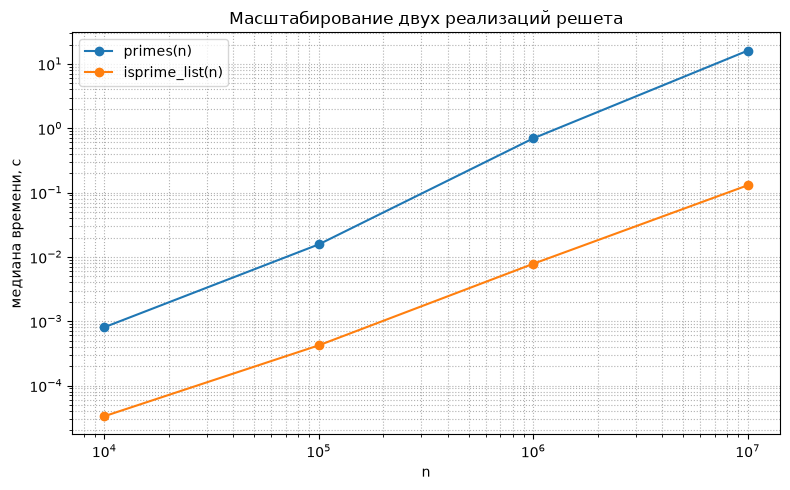

Почему времена разные.
primes заранее не берёт чётные числа: в списке X только нечётные от 3 до n.
Дальше для каждого простого p составное с наименьшим простым делителем q
проверяется заново всеми простыми, меньшими q. Простое больше sqrt(n)
проверяется каждым p <= sqrt(n). Вычёркивание начинается не с p^2,
а со всего оставшегося списка, поэтому числа меньше p^2 тоже проходят
проверку делимости. Среза нет: каждый проход — цикл и новый список на Python.

isprime_list тоже вычёркивает кратные простых, не превосходящих sqrt(n).
Чётные с 4 отмечаются одним срезом flags[4::2] и больше не служат основанием
решета. Для нечётного простого p срез flags[p*p::2*p] пишет False только
нечётным кратным, начиная с p^2. Одно и то же составное может быть отмечено
несколько раз — по разу на каждый нечётный простой делитель, — но отметку
делает срез, а не цикл по кандидатам в интерпретаторе.

Вывод.
Прогноз подтвердился по направлению. isprime_list быстрее на всех n,
и отношение медиан растёт. При увелич

In [30]:
# Выполните исследование здесь:

from statistics import median
from time import perf_counter

import matplotlib.pyplot as plt

print(
    "Прогноз, до измерений.\n"
    "Быстрее будет isprime_list, и отрыв будет расти вместе с n.\n"
    "primes для каждого простого p <= sqrt(n) заново просматривает весь\n"
    "список уцелевших кандидатов из Python и собирает новый список.\n"
    "Таких просмотров порядка n * pi(sqrt(n)), то есть n^(3/2) / log n.\n"
    "isprime_list отмечает прогрессию одним срезом. Число отметок порядка\n"
    "n log log n, а внутренний проход среза не идёт циклом интерпретатора.\n"
    "Отношение времён поэтому должно расти примерно как sqrt(n) / log n."
)

sizes = [10**4, 10**5, 10**6, 10**7]
n_runs = 3

print()
print("Одинаковый набор простых перед сравнением времени.")
for n in sizes:
    from_primes = primes(n)
    from_flags = where(isprime_list(n))
    if from_primes != from_flags:
        raise RuntimeError(f"расхождение при n = {n}")
    print(f"n = {n}: оба списка содержат {len(from_primes)} простых")

median_primes = []
median_flags = []

print()
print(f"Медиана {n_runs} запусков.")
for n in sizes:
    prime_times = []
    flag_times = []
    for _ in range(n_runs):
        start = perf_counter()
        primes(n)
        prime_times.append(perf_counter() - start)

        start = perf_counter()
        isprime_list(n)
        flag_times.append(perf_counter() - start)

    median_primes.append(median(prime_times))
    median_flags.append(median(flag_times))
    print(f"n = {n}")
    print("  primes, с:", [f"{t:.6f}" for t in prime_times], f"медиана {median_primes[-1]:.6f}")
    print("  isprime_list, с:", [f"{t:.6f}" for t in flag_times], f"медиана {median_flags[-1]:.6f}")
    print(f"  отношение медиан: {median_primes[-1] / median_flags[-1]:.1f}")

print()
print("Насколько время вырастает при увеличении n в 10 раз.")
for i in range(1, len(sizes)):
    prime_factor = median_primes[i] / median_primes[i - 1]
    flag_factor = median_flags[i] / median_flags[i - 1]
    print(
        f"  {sizes[i - 1]} -> {sizes[i]}:"
        f" primes ×{prime_factor:.2f}, isprime_list ×{flag_factor:.2f}"
    )

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sizes, median_primes, marker="o", label="primes(n)")
ax.plot(sizes, median_flags, marker="o", label="isprime_list(n)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("n")
ax.set_ylabel("медиана времени, с")
ax.set_title("Масштабирование двух реализаций решета")
ax.grid(True, which="both", linestyle=":")
ax.legend()
fig.tight_layout()
plt.show()

print(
    "Почему времена разные.\n"
    "primes заранее не берёт чётные числа: в списке X только нечётные от 3 до n.\n"
    "Дальше для каждого простого p составное с наименьшим простым делителем q\n"
    "проверяется заново всеми простыми, меньшими q. Простое больше sqrt(n)\n"
    "проверяется каждым p <= sqrt(n). Вычёркивание начинается не с p^2,\n"
    "а со всего оставшегося списка, поэтому числа меньше p^2 тоже проходят\n"
    "проверку делимости. Среза нет: каждый проход — цикл и новый список на Python.\n"
    "\n"
    "isprime_list тоже вычёркивает кратные простых, не превосходящих sqrt(n).\n"
    "Чётные с 4 отмечаются одним срезом flags[4::2] и больше не служат основанием\n"
    "решета. Для нечётного простого p срез flags[p*p::2*p] пишет False только\n"
    "нечётным кратным, начиная с p^2. Одно и то же составное может быть отмечено\n"
    "несколько раз — по разу на каждый нечётный простой делитель, — но отметку\n"
    "делает срез, а не цикл по кандидатам в интерпретаторе.\n"
    "\n"
    "Вывод.\n"
    "Прогноз подтвердился по направлению. isprime_list быстрее на всех n,\n"
    "и отношение медиан растёт. При увеличении n в десять раз время primes\n"
    "вырастает в десятки раз. Время isprime_list растёт медленнее, но на этих\n"
    "размерах тоже быстрее прямой пропорциональности: создание списка флагов\n"
    "и обращения к памяти дают большой вклад, а на самом малом n замер короткий.\n"
    "Рост отношения мягче, чем sqrt(n) / log n: отрыв увеличивается,\n"
    "но не в двадцать раз на трёх порядках n.\n"
    "Это разница двух программ на Python, а не приговор идее решета.\n"
    "Обе реализуют одно и то же решето: вычеркнуть кратные простых p <= sqrt(n)\n"
    "и оставить простые, не превосходящие n.\n"
    "Секунды в опыте зависят от представления данных. Список кандидатов и цикл\n"
    "интерпретатора дороже массива флагов и среза.\n"
    "То же решето на bytearray, битовом массиве или на другом языке даст другие\n"
    "секунды. По этому графику нельзя судить о скорости всех реализаций решета.\n"
    "Переносится другое: алгоритм, который заново просматривает уцелевших\n"
    "кандидатов для каждого p, делает порядка n^(3/2) / log n операций,\n"
    "а алгоритм, который отмечает каждую прогрессию за время, пропорциональное\n"
    "её длине, — порядка n log log n. Этот разрыв не связан с языком."
)


<div style="background-color: #1e1c17; padding: 20px; border-radius: 10px; border-left: 4px solid #d39e00;">

### Практика. Функция `prime_range`

После построения решета удобно получить ещё одну небольшую функцию, которая возвращает простые числа из заданного диапазона.

Реализуйте

```python
def prime_range(a, b):
    ...
```

со следующим контрактом:

- аргументы $a$ и $b$ — целые числа;
- функция возвращает список всех простых $p$, для которых
  $$
  a\leq p<b;
  $$
- если $a\geq b$, результатом является пустой список;
- значения $a<2$ должны обрабатываться корректно.

Используйте уже реализованное решето: для одного диапазона не нужно заново вызывать `is_prime_fast(k)` для каждого отдельного $k$.

Проверьте функцию:

1. на нескольких небольших диапазонах, для которых ответ легко получить вручную;
2. на граничных случаях;
3. независимо в SageMath с помощью `prime_range(a, b)`.

**Подумайте:** почему при перечислении большого числа простых в одном ограниченном диапазоне одно решето естественнее многократного независимого запуска проверки простоты?

</div>

In [31]:
# Выполните практику здесь:
# Одно решето до b - 1. Индекс b в список флагов не входит,
# поэтому условие p < b выполняется само. Числа меньше 2 простыми не бывают.

def prime_range(a, b):
    """Список простых p, для которых a <= p < b."""
    if a >= b or b <= 2:
        return []
    lower = a if a >= 2 else 2
    flags = isprime_list(b - 1)
    return [p for p in range(lower, b) if flags[p]]


# 1. Небольшие диапазоны, ответ виден вручную.
manual = {
    (2, 10): [2, 3, 5, 7],
    (3, 10): [3, 5, 7],
    (8, 10): [],
    (7, 8): [7],
    (13, 17): [13],
    (14, 17): [],
    (10, 45): [11, 13, 17, 19, 23, 29, 31, 37, 41, 43],
}
print("1. Сверка с ответом, посчитанным вручную.")
for (a, b), expected in manual.items():
    got = prime_range(a, b)
    print(f"prime_range({a}, {b}) = {got}; совпало = {got == expected}")

# 2. Края: пустой полуинтервал, a < 2, отрицательные границы, a > b.
boundaries = {
    (10, 10): [],
    (10, 3): [],
    (2, 2): [],
    (0, 2): [],
    (0, 3): [2],
    (1, 2): [],
    (-5, 10): [2, 3, 5, 7],
    (-10, -1): [],
    (-3, 3): [2],
}
print("2. Граничные случаи.")
for (a, b), expected in boundaries.items():
    got = prime_range(a, b)
    print(f"prime_range({a}, {b}) = {got}; совпало = {got == expected}")

# prime_range(0, n + 1) — все простые p <= n, как primes(n).
same_as_primes = all(prime_range(0, n + 1) == primes(n) for n in range(0, 201))
print(f"prime_range(0, n + 1) совпадает с primes(n) для 0 <= n <= 200: {same_as_primes}")

# 3. Независимая сверка с SageMath, если это ядро — Sage.
print("3. Сверка с SageMath.")
try:
    from sage.all import prime_range as sage_prime_range
except ImportError:
    sage_prime_range = None

if sage_prime_range is None:
    print("В ядре .venv модуля sage нет, вызов sage.all.prime_range не выполнен.")
else:
    sage_cases = list(manual) + list(boundaries) + [(0, 100), (50, 80), (97, 100)]
    sage_mismatches = []
    for a, b in sage_cases:
        expected = [int(p) for p in sage_prime_range(a, b)]
        if prime_range(a, b) != expected:
            sage_mismatches.append((a, b))
    print(f"Расхождений с sage.prime_range: {len(sage_mismatches)}")

print(
    "Почему одно решето естественнее серии проверок.\n"
    "Решето до B один раз вычёркивает кратные всех простых p <= sqrt(B).\n"
    "После этого любой отрезок внутри 0..B читается по уже готовым флагам.\n"
    "Отдельный is_prime_fast(k) для каждого k из [a, b) заново ищет делители\n"
    "этого k и не пользуется делителями соседей.\n"
    "На длинном отрезке сумма таких проверок больше, чем одно решето длины B:\n"
    "у решета порядок B log log B отметок, а у независимых проверок\n"
    "на каждое k уходит порядка sqrt(k) делений."
)


1. Сверка с ответом, посчитанным вручную.
prime_range(2, 10) = [2, 3, 5, 7]; совпало = True
prime_range(3, 10) = [3, 5, 7]; совпало = True
prime_range(8, 10) = []; совпало = True
prime_range(7, 8) = [7]; совпало = True
prime_range(13, 17) = [13]; совпало = True
prime_range(14, 17) = []; совпало = True
prime_range(10, 45) = [11, 13, 17, 19, 23, 29, 31, 37, 41, 43]; совпало = True
2. Граничные случаи.
prime_range(10, 10) = []; совпало = True
prime_range(10, 3) = []; совпало = True
prime_range(2, 2) = []; совпало = True
prime_range(0, 2) = []; совпало = True
prime_range(0, 3) = [2]; совпало = True
prime_range(1, 2) = []; совпало = True
prime_range(-5, 10) = [2, 3, 5, 7]; совпало = True
prime_range(-10, -1) = []; совпало = True
prime_range(-3, 3) = [2]; совпало = True
prime_range(0, n + 1) совпадает с primes(n) для 0 <= n <= 200: True
3. Сверка с SageMath.
В ядре .venv модуля sage нет, вызов sage.all.prime_range не выполнен.
Почему одно решето естественнее серии проверок.
Решето до B один 

# 5. Анализ данных

Теперь, когда мы научились быстро генерировать список простых чисел, мы можем заняться анализом данных: экспериментальной теорией чисел, чтобы найти тенденции и закономерности в последовательности простых чисел. Со времён Евклида (около 300 г. до н.э.) нам известно, что простых чисел бесконечно много. Но как они распределены? Какая доля чисел является простой и как меняется эта доля на разных числовых промежутках?

Как теоретические вопросы, эти проблемы относятся к области аналитической теории чисел. Однако трудно понять, что именно нужно доказывать, не проведя предварительных экспериментов. И поэтому, по крайней мере, с тех пор, как Гаусс начал изучать свои обширные таблицы простых чисел, математики активно занимаются экспериментальной теорией чисел.

## 5.1 Анализ списка простых чисел

Давайте начнем с создания нашего набора данных: простые числа до 1 миллиона.

In [32]:
prime_list = where(isprime_list(1000000))

In [33]:
len(prime_list) 

78498

In [34]:
prime_list[-1]  # Последнее простое число в нашем списке, перед миллионом.

999983

In [35]:
type(prime_list) # Какой тип этих данных

list

In [36]:
print(prime_list[:100]) # Первые сто простых чисел.

[2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59, 61, 67, 71, 73, 79, 83, 89, 97, 101, 103, 107, 109, 113, 127, 131, 137, 139, 149, 151, 157, 163, 167, 173, 179, 181, 191, 193, 197, 199, 211, 223, 227, 229, 233, 239, 241, 251, 257, 263, 269, 271, 277, 281, 283, 293, 307, 311, 313, 317, 331, 337, 347, 349, 353, 359, 367, 373, 379, 383, 389, 397, 401, 409, 419, 421, 431, 433, 439, 443, 449, 457, 461, 463, 467, 479, 487, 491, 499, 503, 509, 521, 523, 541]


<div style="background-color: #1a1e21; padding: 20px; border-radius: 10px; border-left: 4px solid #007cba;">

### Задание 8
Выбрать из списка `prime_list` простые числа, которые можно представить в форме $4k+1$. Сохранить их в списке `redprimes`. Выбрать из списка `prime_list` простые числа, которые можно представить в форме $4k+3$. Сохранить их в списке `blueprimes`. Сколько простых чисел в этих списках? Проверьте, что сумма их длин равна `len(prime_list) - 1`, и объясните, какое простое число не попало ни в один список.

</div>


In [37]:
# Ваше решение:
# prime_list — простые p <= 10^6, он уже построен в ячейке выше.
# Нечётное число даёт остаток 1 или 3 при делении на 4.
# Единственное чётное простое — 2, и 2 % 4 == 2, поэтому оно ни туда, ни туда.

redprimes = [p for p in prime_list if p % 4 == 1]
blueprimes = [p for p in prime_list if p % 4 == 3]

missed = [p for p in prime_list if p % 4 not in (1, 3)]

print(f"redprimes, вид 4k+1: {len(redprimes)}")
print(f"blueprimes, вид 4k+3: {len(blueprimes)}")
print(f"сумма длин: {len(redprimes) + len(blueprimes)}")
print(f"len(prime_list) - 1 = {len(prime_list) - 1}")
print(f"сумма равна len(prime_list) - 1: {len(redprimes) + len(blueprimes) == len(prime_list) - 1}")
print(f"не попало ни в один список: {missed}")
print(
    "Это 2. Всякое простое больше 2 нечётно, значит сравнимо с 1 или с 3 по модулю 4\n"
    "и попадает ровно в один из списков. Двойка сравнима с 2 по модулю 4."
)


redprimes, вид 4k+1: 39175
blueprimes, вид 4k+3: 39322
сумма длин: 78497
len(prime_list) - 1 = 78497
сумма равна len(prime_list) - 1: True
не попало ни в один список: [2]
Это 2. Всякое простое больше 2 нечётно, значит сравнимо с 1 или с 3 по модулю 4
и попадает ровно в один из списков. Двойка сравнима с 2 по модулю 4.


Должны получиться близкие значения! Кажется, что простые числа равномерно распределены между этими двумя множествами. Остаток от деления на 4 простого числа будет либо 1, либо 3 примерно с одинаковой вероятностью. Доказано, что асимптотически соотношение между количеством элементов в этих двух множествах приближается к 1.

## 5.2 Функция распределения простых чисел

Функция распределения простых чисел
$\pi(x)$ задаёт количество простых чисел, не превосходящих $x$.
Например, $\pi(2)=1$, $\pi(3)=2$, $\pi(4)=2$ и $\pi(5)=3$.

Дадим более формальное определение.

### Определение 5.1. Функция распределения простых чисел

Для $x>0$ **функцией распределения простых чисел** (*prime-counting function*) называется функция

$$
\pi(x)=\sum_{p\leq x}1.
$$

Изучение асимптотического поведения функции $\pi(x)$ является одной из важных задач аналитической теории чисел.

<div style="background-color: #16191b; padding: 20px; border-radius: 10px; border-left: 4px solid #007cba;">

### Задание 9

Напишите функцию `prime_count(x)`, которая вычисляет $\pi(x)$ — количество простых чисел, не превосходящих $x$.

Используйте уже построенный упорядоченный список `prime_list`, а не запускайте решето заново при каждом вызове функции. Для поиска позиции $x$ в упорядоченном списке можно воспользоваться `bisect_right` из модуля `bisect`.

Проверьте функцию на малых значениях и найдите $\pi(1000)$.

</div>


In [39]:
# Ваше решение:
# prime_list упорядочен, поэтому число простых p <= x — это место вставки x справа.
# Решето заново не строится.

from bisect import bisect_right


def prime_count(x):
    """π(x): число простых p <= x по готовому списку prime_list."""
    return bisect_right(prime_list, x)


checks = {
    1: 0,
    2: 1,
    3: 2,
    4: 2,
    5: 3,
    10: 4,
    1000: 168,
    10**6: len(prime_list),
}
print("Проверка на малых x и на границе списка.")
for x, expected in checks.items():
    got = prime_count(x)
    print(f"π({x}) = {got}; совпало = {got == expected}")


Проверка на малых x и на границе списка.
π(1) = 0; совпало = True
π(2) = 1; совпало = True
π(3) = 2; совпало = True
π(4) = 2; совпало = True
π(5) = 3; совпало = True
π(10) = 4; совпало = True
π(1000) = 168; совпало = True
π(1000000) = 78498; совпало = True


# 6. Анализ функции распределения простых чисел


<div style="background-color: #090c0e; padding: 20px; border-radius: 10px; border-left: 4px solid #007cba;">

### Задание 10

Используя `prime_count(x)`, постройте график функции $\pi(x)$ для $1\leq x\leq 10^6$.

Не требуется вычислять $\pi(x)$ для каждого целого $x$: выберите разумную равномерную сетку значений, например с шагом $10^3$. Укажите использованный шаг.

</div>


Шаг сетки: 1000
Узлов: 1000, от 1000 до 1000000
π(1000) = 168, π(10^6) = 78498


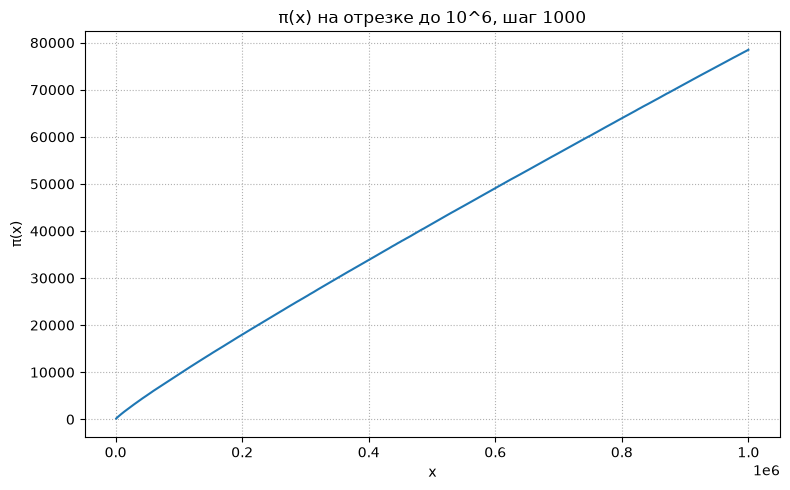

In [40]:
# Ваше решение:
# Сетка равномерная, шаг 1000. Узлы: 1000, 2000, ..., 10^6.
# π(1) = 0 уже проверено в задании 9; на графике шаг начинается с 1000.

import matplotlib.pyplot as plt

step = 10**3
xs = list(range(step, 10**6 + 1, step))
pi_values = [prime_count(x) for x in xs]

print(f"Шаг сетки: {step}")
print(f"Узлов: {len(xs)}, от {xs[0]} до {xs[-1]}")
print(f"π(1000) = {pi_values[0]}, π(10^6) = {pi_values[-1]}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(xs, pi_values)
ax.set_xlabel("x")
ax.set_ylabel("π(x)")
ax.set_title("π(x) на отрезке до 10^6, шаг 1000")
ax.grid(True, linestyle=":")
fig.tight_layout()
plt.show()


Примерный вид ожидаемого графика показан ниже. Конкретный вид может немного отличаться из-за выбранной сетки значений $x$ и масштаба осей:

<img src="attachment:7.png" alt="Примерный график функции pi(x)" width="520">
На первый взгляд можно сказать, что график носит линейный характер. Т.е. это линия вида $\pi(x)=mx$. Тогда, если нарисовать график функции $\pi(x)/x$, то мы увидим константу.

<div style="background-color: #191d20; padding: 20px; border-radius: 10px; border-left: 4px solid #007cba;">

### Задание 11

Постройте график функции $\pi(x)/x$. По полученному результату сделайте вывод, является ли функция $\pi(x)$ линейной или нелинейной.

Примерный вид ожидаемого графика показан ниже. Конкретный вид может немного отличаться из-за выбранной сетки значений $x$ и масштаба осей:

<img src="attachment:8.png" alt="Примерный график отношения pi(x) к x" width="520">

</div>


π(x)/x при x = 1000: 0.168000
π(x)/x при x = 10^6: 0.078498
Максимум на сетке 0.168000, минимум 0.078498. Между соседними узлами отношение иногда чуть растёт.


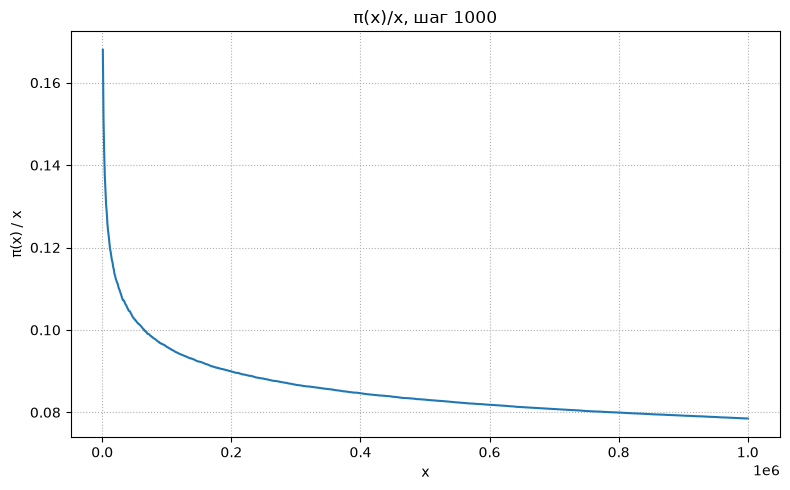

Вывод: π(x) нелинейна.
Линейная функция вида m*x дала бы горизонтальный график π(x)/x.
Здесь от левого конца сетки к правому отношение падает: от 0.168 при x = 1000
до 0.0785 при x = 10^6. По пути бывают мелкие локальные подъёмы,
но горизонтальной прямой нет.
График самого π(x) выглядит почти прямым только потому, что это убывание медленное.


In [41]:
# Ваше решение:
# Та же сетка, что в задании 10: шаг 1000, узлы от 1000 до 10^6.
# Если бы π(x) = m*x, отношение π(x)/x было бы постоянным.

import matplotlib.pyplot as plt

step = 10**3
xs = list(range(step, 10**6 + 1, step))
ratio = [prime_count(x) / x for x in xs]

print(f"π(x)/x при x = 1000: {ratio[0]:.6f}")
print(f"π(x)/x при x = 10^6: {ratio[-1]:.6f}")
print(
    f"Максимум на сетке {max(ratio):.6f}, минимум {min(ratio):.6f}. "
    "Между соседними узлами отношение иногда чуть растёт."
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(xs, ratio)
ax.set_xlabel("x")
ax.set_ylabel("π(x) / x")
ax.set_title("π(x)/x, шаг 1000")
ax.grid(True, linestyle=":")
fig.tight_layout()
plt.show()

print(
    "Вывод: π(x) нелинейна.\n"
    "Линейная функция вида m*x дала бы горизонтальный график π(x)/x.\n"
    "Здесь от левого конца сетки к правому отношение падает: от 0.168 при x = 1000\n"
    "до 0.0785 при x = 10^6. По пути бывают мелкие локальные подъёмы,\n"
    "но горизонтальной прямой нет.\n"
    "График самого π(x) выглядит почти прямым только потому, что это убывание медленное."
)


<div style="background-color: #1c1a16; padding: 20px; border-radius: 10px; border-left: 4px solid #d39e00;">

### 🔬 Исследование. Смещение Чебышёва


Теорема Дирихле утверждает, что в каждом допустимом классе вычетов бесконечно много простых чисел. Её количественное уточнение — теорема о простых числах в арифметических прогрессиях (Ш.-Ж. де ла Валле Пуссен, 1896): простые числа асимптотически равномерно распределяются между допустимыми классами вычетов. В частности, для классов $1$ и $3$ по модулю $4$:

$$
\pi(x;4,1)\sim\pi(x;4,3)\sim\frac12\operatorname{li}(x).
$$

Здесь $\pi(x;4,a)$ — число простых $p\le x$ с $p\equiv a\pmod 4$, а $\operatorname{li}(x)=\int_2^x\frac{dt}{\ln t}$ — интегральный логарифм; подробно он появится в разделе 7.

Поэтому в пределе ни один из этих двух классов не получает положительной доли преимущества над другим.

Однако асимптотическое равенство не означает, что при конечных $x$ разность

$$
\pi(x;4,3)-\pi(x;4,1)
$$

должна одинаково часто принимать положительные и отрицательные значения. Вычисления обнаруживают устойчивую тенденцию: простые числа $p\equiv3\pmod4$ значительно чаще оказываются впереди простых $p\equiv1\pmod4$.

Это явление называется **смещением Чебышёва** (*Chebyshev's bias*). Следующее исследование предлагает сначала обнаружить его экспериментально, а затем отделить наблюдаемое конечное поведение от асимптотического утверждения о равномерном распределении простых по классам вычетов.

Для простых чисел $p>2$ рассмотрим два класса остатков по модулю 4:

$$
p\equiv1\pmod4
\qquad\text{и}\qquad
p\equiv3\pmod4.
$$

Определите функции

$$
\pi_1(x)=\#\{p\leq x:\;p\equiv1\pmod4\},
$$

$$
\pi_3(x)=\#\{p\leq x:\;p\equiv3\pmod4\}.
$$

Вычислите их для набора значений $x$ и постройте график разности

$$
\pi_3(x)-\pi_1(x).
$$

Дополнительно можно построить отношение $\pi_3(x)/\pi_1(x)$.

Исследуйте, наблюдается ли на выбранном диапазоне систематическое преобладание одного из классов.
При интерпретации результата учитывайте, что численный эксперимент на конечном диапазоне сам по себе не доказывает утверждение для всех $x$.

**Для дальнейшего чтения.** Наблюдаемое явление называется **смещением Чебышёва**
(*Chebyshev's bias*) и является частным случаем так называемых **гонок простых чисел**
(*prime number races*). Доступное введение с численными примерами и обсуждением
математической природы эффекта см.:

A. Granville, G. Martin. *Prime Number Races* // The American Mathematical Monthly.
2006. Vol. 113, No. 1. P. 1–33.

Более глубокое исследование:

M. Rubinstein, P. Sarnak. *Chebyshev's Bias* // Experimental Mathematics.
1994. Vol. 3, No. 3. P. 173–197.


</div>


На сетке с шагом 1000: π3 > π1 в 995 узлах, π1 > π3 в 4, поровну в 1
При x = 10^6: π1 = 39175, π3 = 39322, разность = 147
Отношение π3/π1 при x = 10^6: 1.003752
Первый простой, после которого π1 обгоняет π3: 26861
На этом отрезке класс 3 (mod 4) впереди на большинстве узлов сетки,
а отношение π3/π1 близко к 1. Это и есть наблюдаемое смещение Чебышёва:
преимущество небольшое, но устойчивое.
Оно не абсолютно. Есть точки, где вперёд выходит класс 1 (mod 4).
Конечный график не доказывает поведение для всех x.
Теорема о простых в арифметических прогрессиях говорит другое:
π1(x) и π3(x) оба эквивалентны li(x)/2, поэтому отношение стремится к 1,
а разность мала по сравнению с самими функциями.


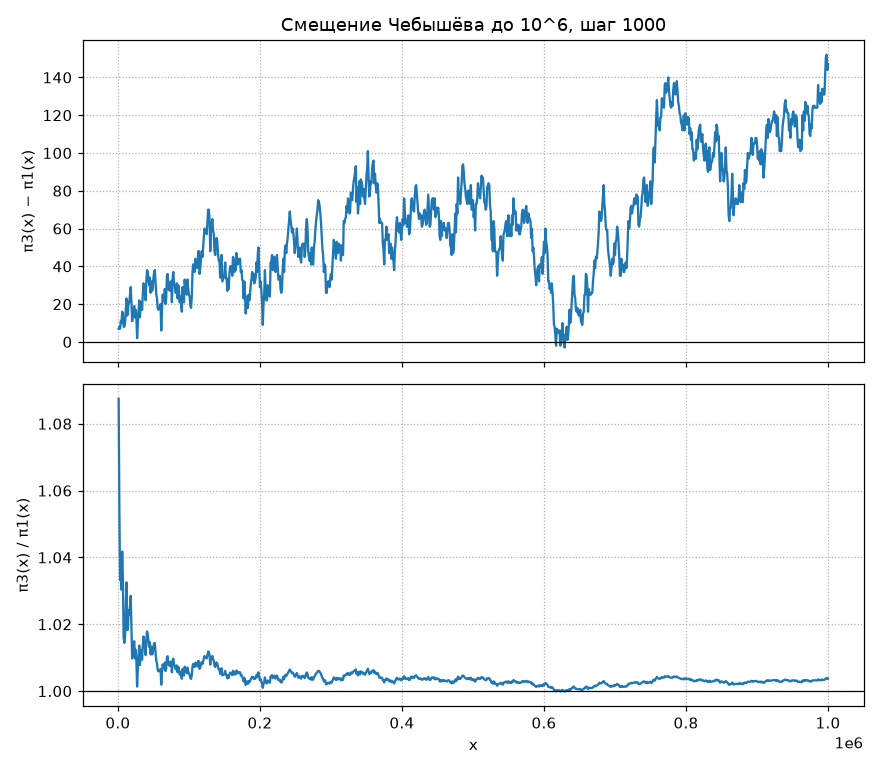

In [14]:
# Выполните исследование здесь:
# redprimes и blueprimes — простые <= 10^6 вида 4k+1 и 4k+3.
# Двойка в них не входит и в эти две функции не считается.

from bisect import bisect_right

import matplotlib.pyplot as plt


def pi1(x):
    return bisect_right(redprimes, x)


def pi3(x):
    return bisect_right(blueprimes, x)


step = 1000
xs = list(range(step, 10**6 + 1, step))
diff = [pi3(x) - pi1(x) for x in xs]
ratio = [pi3(x) / pi1(x) for x in xs]

ahead3 = sum(d > 0 for d in diff)
ahead1 = sum(d < 0 for d in diff)
tie = sum(d == 0 for d in diff)
print(f"На сетке с шагом {step}: π3 > π1 в {ahead3} узлах, π1 > π3 в {ahead1}, поровну в {tie}")
print(f"При x = 10^6: π1 = {pi1(10**6)}, π3 = {pi3(10**6)}, разность = {pi3(10**6) - pi1(10**6)}")
print(f"Отношение π3/π1 при x = 10^6: {pi3(10**6) / pi1(10**6):.6f}")

c1 = c3 = 0
first_lead_of_1 = None
for p in prime_list:
    if p == 2:
        continue
    if p % 4 == 1:
        c1 += 1
    else:
        c3 += 1
    if first_lead_of_1 is None and c1 > c3:
        first_lead_of_1 = p
        break

print(f"Первый простой, после которого π1 обгоняет π3: {first_lead_of_1}")

fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)
axes[0].plot(xs, diff)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("π3(x) − π1(x)")
axes[0].set_title("Смещение Чебышёва до 10^6, шаг 1000")
axes[0].grid(True, linestyle=":")
axes[1].plot(xs, ratio)
axes[1].axhline(1, color="black", linewidth=0.8)
axes[1].set_xlabel("x")
axes[1].set_ylabel("π3(x) / π1(x)")
axes[1].grid(True, linestyle=":")
fig.tight_layout()
plt.show()

print(
    "На этом отрезке класс 3 (mod 4) впереди на большинстве узлов сетки,\n"
    "а отношение π3/π1 близко к 1. Это и есть наблюдаемое смещение Чебышёва:\n"
    "преимущество небольшое, но устойчивое.\n"
    "Оно не абсолютно. Есть точки, где вперёд выходит класс 1 (mod 4).\n"
    "Конечный график не доказывает поведение для всех x.\n"
    "Теорема о простых в арифметических прогрессиях говорит другое:\n"
    "π1(x) и π3(x) оба эквивалентны li(x)/2, поэтому отношение стремится к 1,\n"
    "а разность мала по сравнению с самими функциями."
)


# 7. Асимптотический закон распределения простых чисел

Асимптотический закон распределения простых чисел имеет вид

$$
\pi(x)\sim\frac{x}{\ln x},\qquad x\to\infty.
$$

Это означает, что отношение $\pi(x)$ к $x/\ln x$ стремится к 1 при $x\to\infty$.

<div style="background-color: #0a0c0e; padding: 20px; border-radius: 10px; border-left: 4px solid #007cba;">

### Задание 12
Наложите на график функции $\pi(x) / x$ график функции $1 / \ln(x)$.  
Примерный вид ожидаемого графика показан ниже. Конкретный вид может немного отличаться из-за выбранной сетки значений $x$ и масштаба осей:

<img src="attachment:9.png" alt="Примерное сравнение pi(x)/x и 1/log(x)" width="520">

</div>


x = 1000:  π/x = 0.1680,  1/ln(x) = 0.1448
x = 10^6:  π/x = 0.0785,  1/ln(x) = 0.0724


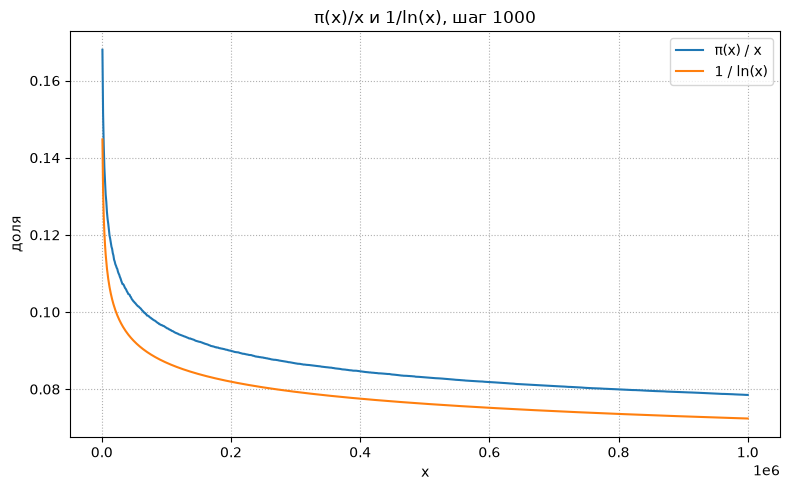

Обе кривые убывают и близки по форме. На всём отрезке π(x)/x лежит выше 1/ln(x):
простых пока больше, чем даёт первое приближение x/ln(x), но закон убывания тот же.


In [42]:
# Ваше решение:
# Та же сетка, что в заданиях 10 и 11: шаг 1000, от 1000 до 10^6.
# ln — натуральный логарифм, как в асимптотике π(x) ~ x / ln(x).

import math

import matplotlib.pyplot as plt

step = 10**3
xs = list(range(step, 10**6 + 1, step))
pi_over_x = [prime_count(x) / x for x in xs]
one_over_ln = [1 / math.log(x) for x in xs]

print(f"x = 1000:  π/x = {pi_over_x[0]:.4f},  1/ln(x) = {one_over_ln[0]:.4f}")
print(f"x = 10^6:  π/x = {pi_over_x[-1]:.4f},  1/ln(x) = {one_over_ln[-1]:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(xs, pi_over_x, label="π(x) / x")
ax.plot(xs, one_over_ln, label="1 / ln(x)")
ax.set_xlabel("x")
ax.set_ylabel("доля")
ax.set_title("π(x)/x и 1/ln(x), шаг 1000")
ax.grid(True, linestyle=":")
ax.legend()
fig.tight_layout()
plt.show()

print(
    "Обе кривые убывают и близки по форме. На всём отрезке π(x)/x лежит выше 1/ln(x):\n"
    "простых пока больше, чем даёт первое приближение x/ln(x), но закон убывания тот же."
)


Асимптотический закон распределения простых чисел известен как теорема о распределении простых чисел (**prime number theorem**):
$$\lim_{x \rightarrow \infty} \frac{\pi(x)}{x / \ln(x)} = 1.$$

<div style="background-color: #060607; padding: 20px; border-radius: 10px; border-left: 4px solid #007cba;">

### Задание 13
Постройте график функции $$\frac{\pi(x)}{x / \ln(x)}.$$  
Примерный вид ожидаемого графика показан ниже. Конкретный вид может немного отличаться из-за выбранной сетки значений $x$ и масштаба осей:

<img src="attachment:10.png" alt="Примерный график отношения pi(x) к x/log(x)" width="520">

</div>


При x = 1000 отношение = 1.1605
При x = 10^6 отношение = 1.0845
Минимум на сетке = 1.0844, максимум = 1.1605


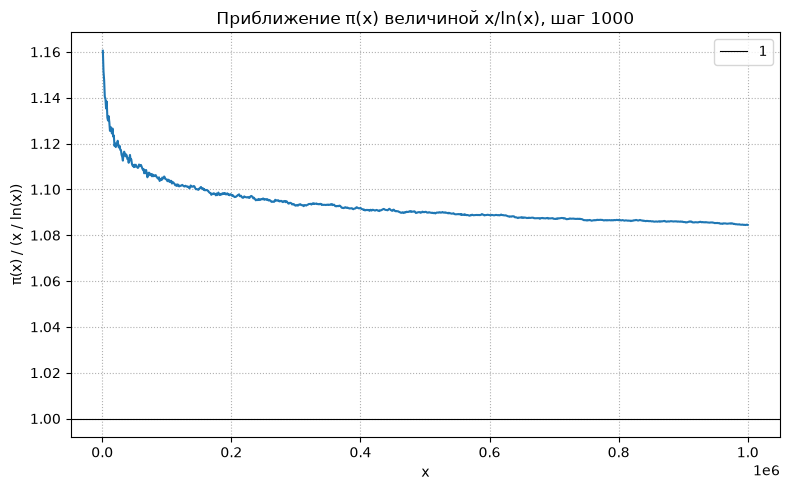

Отношение больше 1 и медленно снижается к 1: от примерно 1.16 при x = 1000
до примерно 1.08 при x = 10^6. Сходимость видна, но к концу отрезка
до единицы ещё далеко. Это согласуется с тем, что x/ln(x) — грубое
первое приближение, а не точное значение π(x).


In [43]:
# Ваше решение:
# π(x) / (x / ln(x)) = π(x) * ln(x) / x.
# Сетка та же: шаг 1000 от 1000 до 10^6.

import math

import matplotlib.pyplot as plt

step = 10**3
xs = list(range(step, 10**6 + 1, step))
ratio = [prime_count(x) * math.log(x) / x for x in xs]

print(f"При x = 1000 отношение = {ratio[0]:.4f}")
print(f"При x = 10^6 отношение = {ratio[-1]:.4f}")
print(f"Минимум на сетке = {min(ratio):.4f}, максимум = {max(ratio):.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(xs, ratio)
ax.axhline(1, color="black", linewidth=0.8, label="1")
ax.set_xlabel("x")
ax.set_ylabel("π(x) / (x / ln(x))")
ax.set_title("Приближение π(x) величиной x/ln(x), шаг 1000")
ax.grid(True, linestyle=":")
ax.legend()
fig.tight_layout()
plt.show()

print(
    "Отношение больше 1 и медленно снижается к 1: от примерно 1.16 при x = 1000\n"
    "до примерно 1.08 при x = 10^6. Сходимость видна, но к концу отрезка\n"
    "до единицы ещё далеко. Это согласуется с тем, что x/ln(x) — грубое\n"
    "первое приближение, а не точное значение π(x)."
)


Видно, что есть сходимость к 1, но очень медленная.

>Существует асимптотический закон распределения в следующей форме:  
$$\pi(x)\sim \operatorname{li}(x), x\to\infty,$$
где
$$\operatorname{li}(x) = \int_{2}^{x} \frac{dt}{\ln t}$$ - интегральный логарифм.

**Замечание о вычислении.** В пакете `mpmath` функция `li(x)` по умолчанию считает интеграл от $0$ (в смысле главного значения), который больше на $\int_0^2\frac{dt}{\ln t}\approx1{,}045$. Интеграл от $2$, как в нашем определении, даёт `li(x, offset=True)`. Для отношений $\pi(x)/\operatorname{li}(x)$ разница несущественна, но в таблицах значений её нужно учитывать.


<div style="background-color: #020202; padding: 20px; border-radius: 10px; border-left: 4px solid #007cba;">

### Задание 14

Постройте график функции

$$
\frac{\pi(x)}{\operatorname{li}(x)}.
$$

Интегральный логарифм не входит в стандартную библиотеку Python и `numpy`, но функция `li` доступна в пакете `mpmath`:

```python
from mpmath import li

li(x, offset=True)   # интеграл от 2 — как в нашем определении
```

Примерный вид ожидаемого графика показан ниже. Конкретный вид может немного отличаться из-за выбранной сетки значений $x$ и масштаба осей:

<img src="attachment:11.png" alt="Примерный график отношения pi(x) к li(x)" width="520">

</div>


При x = 1000: π/li = 0.951494, li = 176.56
При x = 10^6: π/li = 0.998366, li = 78626.50


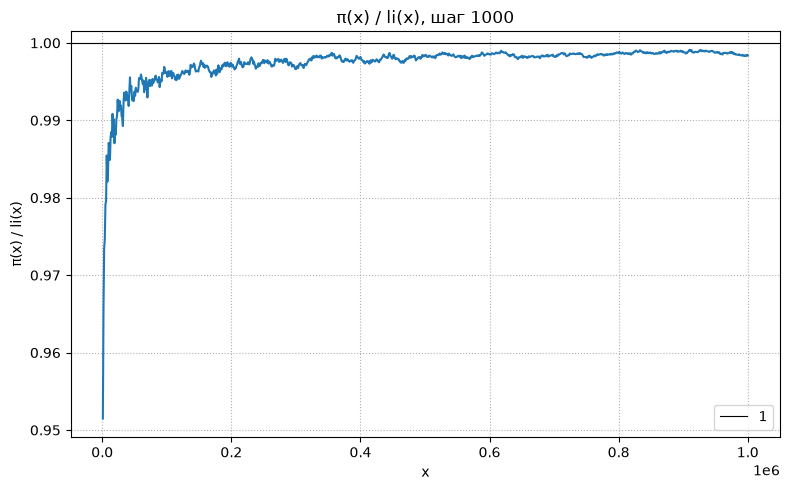

Отношение чуть меньше 1 и ближе к единице, чем π(x) / (x/ln(x)).
li(x) слегка завышает число простых, но уже при x = 10^6 относительный
зазор составляет доли процента. На графике это почти горизонталь у отметки 1.


In [44]:
# Ваше решение:
# li(x, offset=True) — интеграл от 2 до x, как в определении раздела.
# Сетка та же: шаг 1000 от 1000 до 10^6.

import matplotlib.pyplot as plt
from mpmath import li

step = 10**3
xs = list(range(step, 10**6 + 1, step))
ratio = [prime_count(x) / float(li(x, offset=True)) for x in xs]

print(f"При x = 1000: π/li = {ratio[0]:.6f}, li = {float(li(1000, offset=True)):.2f}")
print(f"При x = 10^6: π/li = {ratio[-1]:.6f}, li = {float(li(10**6, offset=True)):.2f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(xs, ratio)
ax.axhline(1, color="black", linewidth=0.8, label="1")
ax.set_xlabel("x")
ax.set_ylabel("π(x) / li(x)")
ax.set_title("π(x) / li(x), шаг 1000")
ax.grid(True, linestyle=":")
ax.legend()
fig.tight_layout()
plt.show()

print(
    "Отношение чуть меньше 1 и ближе к единице, чем π(x) / (x/ln(x)).\n"
    "li(x) слегка завышает число простых, но уже при x = 10^6 относительный\n"
    "зазор составляет доли процента. На графике это почти горизонталь у отметки 1."
)


<div style="background-color: #252c30; padding: 20px; border-radius: 10px; border-left: 4px solid #007cba;">

### Задание 15

Гипотеза Римана равносильна оценке (Х. фон Кох, 1901)

$$
\left|\pi(x)-\operatorname{li}(x)\right|
=O\!\left(\sqrt{x}\,\ln x\right).
$$

Численно исследуйте величину

$$
\frac{\left|\pi(x)-\operatorname{li}(x)\right|}
{\sqrt{x}\,\ln x}
$$

на рассматриваемом диапазоне значений $x$. Постройте график этой величины и опишите наблюдаемое поведение.

**Важно:** численный эксперимент на конечном диапазоне не является доказательством приведённой асимптотической оценки или гипотезы Римана.

</div>


При x = 1000 величина = 0.039207
При x = 10^6 величина = 0.009301
Максимум на сетке = 0.039207, минимум = 0.004883


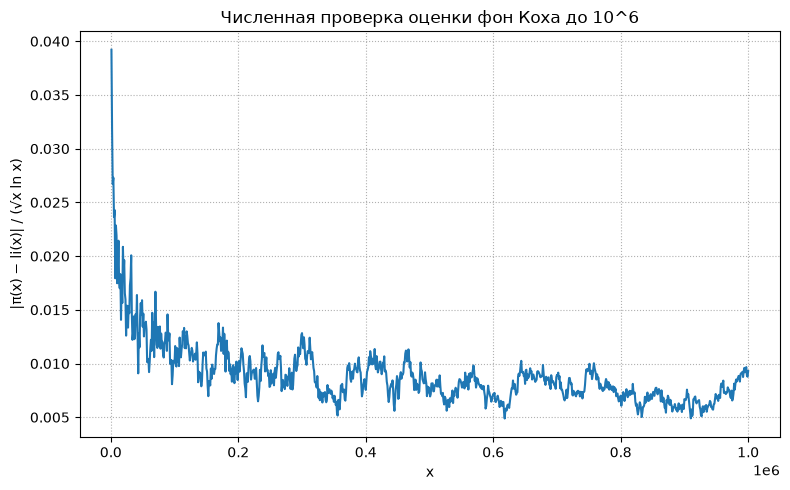

На этом отрезке величина остаётся порядка сотых и к правому концу
становится меньше, чем в начале. Роста, который ломал бы оценку
O(sqrt(x) ln x), не видно.
Это наблюдение на конечном отрезке. Оно не доказывает ни оценку фон Коха
для всех x, ни гипотезу Римана.


In [45]:
# Ваше решение:
# Смотрим, остаётся ли |π(x) - li(x)| / (sqrt(x) ln(x)) малой на сетке до 10^6.
# Конечный график не доказывает оценку фон Коха и не доказывает гипотезу Римана.

import math

import matplotlib.pyplot as plt
from mpmath import li

step = 10**3
xs = list(range(step, 10**6 + 1, step))
values = []
for x in xs:
    gap = abs(prime_count(x) - float(li(x, offset=True)))
    values.append(gap / (math.sqrt(x) * math.log(x)))

print(f"При x = 1000 величина = {values[0]:.6f}")
print(f"При x = 10^6 величина = {values[-1]:.6f}")
print(f"Максимум на сетке = {max(values):.6f}, минимум = {min(values):.6f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(xs, values)
ax.set_xlabel("x")
ax.set_ylabel("|π(x) − li(x)| / (√x ln x)")
ax.set_title("Численная проверка оценки фон Коха до 10^6")
ax.grid(True, linestyle=":")
fig.tight_layout()
plt.show()

print(
    "На этом отрезке величина остаётся порядка сотых и к правому концу\n"
    "становится меньше, чем в начале. Роста, который ломал бы оценку\n"
    "O(sqrt(x) ln x), не видно.\n"
    "Это наблюдение на конечном отрезке. Оно не доказывает ни оценку фон Коха\n"
    "для всех x, ни гипотезу Римана."
)


<div style="background-color: #20262b; padding: 20px; border-radius: 10px; border-left: 4px solid #007cba;">

### Задание 16

Найдите относительную погрешность приближения

$$
\pi(x)\approx\operatorname{li}(x)
$$

для значений

$$
x=10^6,\;10^7,\;10^8,\;10^9.
$$

Используйте относительную погрешность

$$
\varepsilon(x)=
\frac{\left|\operatorname{li}(x)-\pi(x)\right|}{\pi(x)}.
$$

Для $x>10^6$ **не создавайте** список `flags` (тип `list`) длиной $x+1$: такая реализация решета в Python расходует слишком много памяти (8 байт на ссылку, около 8 ГБ при $x=10^9$).

Точные значения $\pi(x)$ можно получить независимо в **SageMath** с помощью функции

```python
prime_pi(x)
```

Если SageMath не установлен локально, воспользуйтесь онлайн-средой [SageMathCell](https://sagecell.sagemath.org/). Например:

```python
prime_pi(10^9)
```

Значение $\operatorname{li}(x)$ вычислите в Python с помощью `mpmath.li(x, offset=True)` — это интеграл от $2$, как в определении раздела 7.

Для ориентира рассмотрим два примера сравнения $\pi(x)$ с приближениями $x/\ln x$ и $\operatorname{li}(x)$:

| $x$ | $\pi(x)$ | $x/\ln x$ | Относительная погрешность | $\operatorname{li}(x)$ | Относительная погрешность |
| ---: | ---: | ---: | ---: | ---: | ---: |
| $10^3$ | $168$ | $145$ | $\approx 13.8\%$ | $177$ | $\approx 5.1\%$ |
| $10^6$ | $78\,498$ | $72\,382$ | $\approx 7.8\%$ | $78\,627$ | $\approx 0.16\%$ |

В таблице $\operatorname{li}(x)=\int_2^x dt/\ln t$ (`offset=True`); погрешности вычислены по неокруглённым значениям.

Вычислите $\varepsilon(x)$ для всех указанных в задании значений $x$ и сравните полученные результаты.

**Сделайте вывод:** как изменяется относительная погрешность приближения $\operatorname{li}(x)$ при росте $x$? Что показывают результаты эксперимента о качестве приближения $\pi(x)\approx\operatorname{li}(x)$ на рассматриваемом диапазоне?

</div>

In [50]:
# Ваше решение:
# SageMath в этом ядре нет. π(x) для больших x считает решето на bytearray:
# один байт на число, а не список ссылок. При x = 10^6 результат сверяется
# с prime_count. li(x) — mpmath.li(x, offset=True), интеграл от 2.

import math
from math import isqrt

from mpmath import li


def pi_bytearray(n):
    """Число простых p <= n. Флаги хранятся в bytearray."""
    if n < 2:
        return 0
    flags = bytearray(b"\x01") * (n + 1)
    flags[0] = flags[1] = 0
    if n >= 4:
        flags[4::2] = bytes(len(flags[4::2]))
    p = 3
    limit = isqrt(n)
    while p <= limit:
        if flags[p]:
            start = p * p
            step = 2 * p
            block = flags[start::step]
            flags[start::step] = bytes(len(block))
        p += 2
    return flags.count(1)


print(f"Сверка π(10^6): bytearray = {pi_bytearray(10**6)}, prime_count = {prime_count(10**6)}")

print(f"{'x':>12} {'π(x)':>12} {'x/ln x':>12} {'ε, x/ln':>10} {'li(x)':>12} {'ε, li':>10}")
errors_li = []
for exponent in range(6, 10):
    x = 10**exponent
    pi_x = pi_bytearray(x)
    log_approx = x / math.log(x)
    li_x = float(li(x, offset=True))
    eps_log = abs(log_approx - pi_x) / pi_x
    eps_li = abs(li_x - pi_x) / pi_x
    errors_li.append(eps_li)
    print(
        f"{x:12d} {pi_x:12d} {log_approx:12.1f} {eps_log:10.4%}"
        f" {li_x:12.1f} {eps_li:10.4%}"
    )

decreasing = all(errors_li[i] > errors_li[i + 1] for i in range(len(errors_li) - 1))
print(f"Относительная погрешность li убывает на 10^6 … 10^9: {decreasing}")
print(
    "Вывод. С ростом x погрешность li(x) уменьшается и на всём этом диапазоне\n"
    "она заметно меньше погрешности x/ln(x). Приближение π(x) ≈ li(x) на отрезке\n"
    "от миллиона до миллиарда уже хорошее и становится лучше.\n"
    "Таблица — конечный эксперимент: она согласуется с π(x) ~ li(x),\n"
    "но не заменяет доказательства асимптотики."
)


Сверка π(10^6): bytearray = 78498, prime_count = 78498
           x         π(x)       x/ln x    ε, x/ln        li(x)      ε, li
     1000000        78498      72382.4    7.7908%      78626.5    0.1637%
    10000000       664579     620420.7    6.6446%     664917.4    0.0509%
   100000000      5761455    5428681.0    5.7759%    5762208.3    0.0131%
  1000000000     50847534   48254942.4    5.0988%   50849233.9    0.0033%
Относительная погрешность li убывает на 10^6 … 10^9: True
Вывод. С ростом x погрешность li(x) уменьшается и на всём этом диапазоне
она заметно меньше погрешности x/ln(x). Приближение π(x) ≈ li(x) на отрезке
от миллиона до миллиарда уже хорошее и становится лучше.
Таблица — конечный эксперимент: она согласуется с π(x) ~ li(x),
но не заменяет доказательства асимптотики.


<div style="border-left: 3px solid #666; padding-left: 18px; margin: 18px 0;">

**Почему это важно?** В SageMath уже есть функция `next_prime(n)`, которая возвращает наименьшее простое число, строго большее $n$. Построим её учебный аналог на основе уже реализованной проверки простоты. Это свяжет алгоритм поиска простых чисел со следующим разделом о промежутках между простыми.

</div>

<div style="background-color: #2a3034; padding: 20px; border-radius: 10px; border-left: 4px solid #007cba;">

### Задание 17

Реализуйте функцию

```python
def next_prime(n):
    ...
```

которая для целого $n$ возвращает **наименьшее простое число $p>n$**.

1. Сформулируйте контракт функции и отдельно проверьте случаи $n<2$, $n=2$ и чётные значения $n$.
2. После обработки числа $2$ не перебирайте чётные кандидаты: объясните, почему достаточно переходить от одного нечётного кандидата к следующему с шагом $2$.
3. Для проверки простоты кандидата используйте ранее реализованную `is_prime_fast`.
4. Проверьте функцию на нескольких небольших значениях, для которых ответ легко установить вручную.
5. Выполните независимую проверку результатов в SageMath с помощью `next_prime(n)` (или метода `ZZ(n).next_prime()`).
6. Для нескольких значений $n$ вычислите величину
   $$
   d(n)=\operatorname{next\_prime}(n)-n.
   $$
   Что измеряет $d(n)$? В каком случае эта величина является промежутком между двумя последовательными простыми числами?

**Важно.** Это учебная реализация. Её эффективность определяется используемым тестом простоты. Позже мы заменим перебор делителей вероятностным тестом простоты, пригодным для существенно больших чисел.

</div>

In [53]:
# Ваше решение:
# Контракт: next_prime(n) — наименьшее простое p > n для целого n.
# Если n < 2, это простое равно 2. Если n = 2, следующее простое равно 3.
# is_prime_fast написана в задании 3. Здесь она определяется ещё раз,
# чтобы ячейка работала, даже если задание 3 в этом сеансе не запускали.

import math


def is_prime_fast(n):
    """Проверка простоты перебором делителей до floor(sqrt(n))."""
    if n < 2:
        return False
    if n % 2 == 0:
        return n == 2
    limit = math.isqrt(n)
    for d in range(3, limit + 1, 2):
        if n % d == 0:
            return False
    return True


def next_prime(n):
    """Наименьшее простое число, строго большее n."""
    if n < 2:
        return 2
    if n == 2:
        return 3
    candidate = n + 1
    if candidate % 2 == 0:
        candidate += 1
    while not is_prime_fast(candidate):
        candidate += 2
    return candidate


print("1–2. После двойки все простые нечётны, поэтому чётный кандидат заведомо составной.")
print("Достаточно шага 2 по нечётным числам. Чётные после 2 в перебор не входят.")
manual = {
    -5: 2,
    0: 2,
    1: 2,
    2: 3,
    3: 5,
    4: 5,
    8: 11,
    9: 11,
    13: 17,
    14: 17,
}
print("4. Сверка вручную.")
for n, expected in manual.items():
    got = next_prime(n)
    print(f"next_prime({n}) = {got}; совпало = {got == expected}")

print("5. SageMath.")
try:
    from sage.all import next_prime as sage_next_prime
except ImportError:
    sage_next_prime = None
if sage_next_prime is None:
    print("В ядре .venv модуля sage нет, sage.all.next_prime не вызван.")
else:
    mismatches = [n for n in manual if next_prime(n) != int(sage_next_prime(n))]
    print(f"Расхождений с Sage: {len(mismatches)}")

print("6. d(n) = next_prime(n) - n — расстояние от n до ближайшего простого сверху.")
for n in (10, 11, 14, 97):
    d = next_prime(n) - n
    print(f"d({n}) = {d}")
print(
    "Если n само простое, d(n) = p_{k+1} - p_k: это промежуток между\n"
    "двумя последовательными простыми. Если n составное, d(n) — только\n"
    "хвост того промежутка, внутри которого лежит n, а не весь промежуток."
)


1–2. После двойки все простые нечётны, поэтому чётный кандидат заведомо составной.
Достаточно шага 2 по нечётным числам. Чётные после 2 в перебор не входят.
4. Сверка вручную.
next_prime(-5) = 2; совпало = True
next_prime(0) = 2; совпало = True
next_prime(1) = 2; совпало = True
next_prime(2) = 3; совпало = True
next_prime(3) = 5; совпало = True
next_prime(4) = 5; совпало = True
next_prime(8) = 11; совпало = True
next_prime(9) = 11; совпало = True
next_prime(13) = 17; совпало = True
next_prime(14) = 17; совпало = True
5. SageMath.
В ядре .venv модуля sage нет, sage.all.next_prime не вызван.
6. d(n) = next_prime(n) - n — расстояние от n до ближайшего простого сверху.
d(10) = 1
d(11) = 2
d(14) = 3
d(97) = 4
Если n само простое, d(n) = p_{k+1} - p_k: это промежуток между
двумя последовательными простыми. Если n составное, d(n) — только
хвост того промежутка, внутри которого лежит n, а не весь промежуток.


<div style="background-color: #272419; padding: 20px; border-radius: 10px; border-left: 4px solid #d39e00;">

### Challenge. Функция `previous_prime`

Постройте симметричную к `next_prime` функцию

```python
def previous_prime(n):
    ...
```

которая возвращает **наибольшее простое число $p<n$**.

1. Сформулируйте контракт функции.
2. Определите, что должна делать функция при $n\leq2$: возвращать специальное значение или возбуждать исключение. Обоснуйте выбранный контракт.
3. После обработки числа $2$ используйте только нечётные кандидаты.
4. Переиспользуйте ранее реализованную `is_prime_fast`, а не дублируйте код проверки простоты.
5. Проверьте несколько значений вручную и независимо в SageMath с помощью `previous_prime(n)` или `ZZ(n).previous_prime()`.
6. Сравните структуры `next_prime` и `previous_prime`: какие части алгоритма совпадают, а где появляются различные граничные случаи?

</div>

In [54]:
# Выполните Challenge здесь:
# Контракт: previous_prime(n) — наибольшее простое p < n.
# При n <= 2 такого простого нет. Исключение честнее, чем выдуманное число:
# область функции — целые n > 2. Так же поступает Sage.
# Проверка простоты — та же is_prime_fast, что в задании 17.

import math


def is_prime_fast(n):
    """Проверка простоты перебором делителей до floor(sqrt(n))."""
    if n < 2:
        return False
    if n % 2 == 0:
        return n == 2
    limit = math.isqrt(n)
    for d in range(3, limit + 1, 2):
        if n % d == 0:
            return False
    return True


def previous_prime(n):
    """Наибольшее простое число, строго меньшее n. При n <= 2 возбуждает ValueError."""
    if n <= 2:
        raise ValueError("простого числа, меньшего n, нет")
    if n == 3:
        return 2
    candidate = n - 1
    if candidate % 2 == 0:
        candidate -= 1
    while not is_prime_fast(candidate):
        candidate -= 2
    return candidate


manual = {3: 2, 4: 3, 5: 3, 8: 7, 10: 7, 15: 13, 18: 17}
print("Проверка вручную.")
for n, expected in manual.items():
    got = previous_prime(n)
    print(f"previous_prime({n}) = {got}; совпало = {got == expected}")

for n in (0, 1, 2):
    try:
        previous_prime(n)
    except ValueError as error:
        print(f"previous_prime({n}): ValueError ({error})")

print("SageMath.")
try:
    from sage.all import previous_prime as sage_previous_prime
except ImportError:
    sage_previous_prime = None
if sage_previous_prime is None:
    print("В ядре .venv модуля sage нет, sage.all.previous_prime не вызван.")
else:
    mismatches = [n for n in manual if previous_prime(n) != int(sage_previous_prime(n))]
    print(f"Расхождений с Sage: {len(mismatches)}")

print(
    "Сравнение с next_prime.\n"
    "Совпадает основа: отдельно обрабатывается 2, дальше шаг 2 по нечётным\n"
    "кандидатам и та же is_prime_fast.\n"
    "Различается край. next_prime определена для всех целых и при n < 2\n"
    "возвращает 2: сверху простое всегда есть. previous_prime упирается\n"
    "в то, что меньше 2 простых нет, поэтому при n <= 2 возбуждает ValueError."
)


Проверка вручную.
previous_prime(3) = 2; совпало = True
previous_prime(4) = 3; совпало = True
previous_prime(5) = 3; совпало = True
previous_prime(8) = 7; совпало = True
previous_prime(10) = 7; совпало = True
previous_prime(15) = 13; совпало = True
previous_prime(18) = 17; совпало = True
previous_prime(0): ValueError (простого числа, меньшего n, нет)
previous_prime(1): ValueError (простого числа, меньшего n, нет)
previous_prime(2): ValueError (простого числа, меньшего n, нет)
SageMath.
В ядре .venv модуля sage нет, sage.all.previous_prime не вызван.
Сравнение с next_prime.
Совпадает основа: отдельно обрабатывается 2, дальше шаг 2 по нечётным
кандидатам и та же is_prime_fast.
Различается край. next_prime определена для всех целых и при n < 2
возвращает 2: сверху простое всегда есть. previous_prime упирается
в то, что меньше 2 простых нет, поэтому при n <= 2 возбуждает ValueError.


<div style="border-left: 3px solid #666; padding-left: 18px; margin: 18px 0;">

**Наш API и SageMath.** К этому моменту у нас появились собственные учебные реализации нескольких стандартных операций с простыми числами. SageMath удобно использовать как **независимый инструмент проверки**, но не как замену выводу алгоритма, доказательству корректности и анализу сложности.

| Наша учебная функция | SageMath | Что сравниваем |
| --- | --- | --- |
| `is_prime_fast(n)` | `is_prime(n)` | простое ли число $n$ |
| `where(isprime_list(n))` | `prime_range(0, n + 1)` | все простые числа, не превосходящие $n$ |
| `prime_range(a, b)` | `prime_range(a, b)` | простые числа в полуинтервале $[a,b)$ |
| `prime_count(x)` | `prime_pi(x)` | значение функции $\pi(x)$ |
| `next_prime(n)` | `next_prime(n)` | ближайшее простое строго справа от $n$ |
| `previous_prime(n)` | `previous_prime(n)` | ближайшее простое строго слева от $n$ |

Если SageMath не установлен локально, небольшие проверки можно выполнять в [SageMathCell](https://sagecell.sagemath.org/).

Совпадение результатов двух независимых реализаций — полезный тест, но **не доказательство корректности**. Для учебной реализации по-прежнему нужно понимать математическую идею, контракт, граничные случаи и стоимость алгоритма.

</div>

# 8. Промежутки между простыми числами (prime gaps)

Изучение распределения промежутков между простыми числами является важной задачей теории чисел.
$n$-й промежуток между последовательными простыми числами определяется как

$$
g_n=p_{n+1}-p_n.
$$

Начало последовательности промежутков:
$(3-2=1), (5-3=2), (7-5=2), (11-7=4), (13-11=2), (17-13=4),\ldots$

Несколько простых наблюдений:

- $g_n$ всегда чётен при $p_n>2$, поскольку все простые числа больше 2 нечётны;
- $g_n\geq2$ для всех $n>1$;
- $g_n=2$ для пар простых-близнецов, например $(3,5)$, $(5,7)$, $(11,13)$.

## 8.1. Средний масштаб промежутка

В предыдущем разделе мы использовали асимптотический закон распределения простых чисел

$$
\pi(x)\sim\frac{x}{\ln x}.
$$

Среди чисел от $1$ до $x$ находится примерно $\pi(x)$ простых. Поэтому среднее расстояние между простыми на всём отрезке до $x$ имеет масштаб

$$
\frac{x}{\pi(x)}.
$$

Подставляя асимптотику для $\pi(x)$, получаем

$$
\frac{x}{\pi(x)}
\sim
\ln x.
$$

Таким образом, **средний масштаб промежутка между простыми числами около больших значений $x$ естественно сравнивать с $\ln x$**. Это объясняет, почему по мере роста $x$ простые числа в среднем встречаются реже.

Важно различать глобальную среднюю закономерность и конкретные локальные промежутки: отдельный $g_n$ может быть существенно меньше или существенно больше $\ln p_n$.

Для сравнения промежутков, возникающих при разных размерах чисел, удобно рассматривать **нормированный промежуток**

$$
\rho_n=\frac{g_n}{\ln p_n}.
$$

Величина $\rho_n$ показывает размер конкретного промежутка в единицах естественного среднего масштаба $\ln p_n$.


## 8.2. Сколь угодно большие промежутки

<div style="border-top: 1px solid #999; border-bottom: 1px solid #999; padding: 12px 4px; margin: 18px 0;">

<strong>Предложение 8.1. Существование сколь угодно длинных последовательностей составных чисел</strong>

Для любого натурального $m$ существуют $m$ последовательных составных чисел. Следовательно, промежутки между последовательными простыми числами не ограничены сверху.

</div>

**Доказательство.** Рассмотрим числа

$$
(m+1)!+2,\;(m+1)!+3,\;\ldots,\;(m+1)!+(m+1).
$$

Их ровно $m$. Для каждого целого $k$, где $2\leq k\leq m+1$, число $k$ делит $(m+1)!$. Поэтому

$$
k\mid\bigl((m+1)!+k\bigr).
$$

При этом $(m+1)!+k>k$, следовательно, $(m+1)!+k$ является составным. Мы получили $m$ последовательных составных чисел.

Так как $m$ можно выбрать сколь угодно большим, существуют сколь угодно длинные участки без простых чисел. Следовательно, последовательность промежутков $g_n$ не ограничена сверху. $\square$

<div style="border-left: 3px solid #666; padding-left: 18px; margin: 18px 0;">

**Что произошло?** Асимптотика $\pi(x)\sim x/\ln x$ описывает среднюю плотность простых чисел, но не запрещает больших локальных отклонений. Факториальная конструкция явно создаёт длинный интервал, в котором простых чисел нет вообще.

</div>


## 8.3. Малые промежутки и современная картина

Противоположный вопрос — насколько часто простые числа могут находиться очень близко друг к другу.

Гипотеза о простых числах-близнецах утверждает, что существует бесконечно много пар простых чисел,
различающихся на $2$, то есть бесконечно много индексов $n$, для которых

$$
g_n=2.
$$

Эта гипотеза до сих пор не доказана.

В то же время современная теория даёт более слабый, но принципиально важный результат: существует некоторая абсолютная константа $B$, такая что для бесконечно многих $n$

$$
p_{n+1}-p_n\leq B.
$$

Иными словами, доказано существование **ограниченных промежутков между простыми числами** (*bounded gaps between primes*), хотя значение $B=2$, соответствующее гипотезе о простых-близнецах, пока недоступно.

В этом курсе мы не будем доказывать теоремы об ограниченных промежутках: их доказательства используют развитые методы аналитической теории чисел и решет. Для нас важнее вычислительно увидеть одновременно две особенности последовательности простых:

- абсолютные промежутки $g_n$ могут становиться очень большими;
- при сравнении промежутков на разных масштабах естественно учитывать нормировку $g_n/\ln p_n$.


<div style="background-color: #23292e; padding: 20px; border-radius: 10px; border-left: 4px solid #007cba;">

### Задание 18

Для простых чисел, не превосходящих $10^6$, вычислите промежутки

$$
g_n=p_{n+1}-p_n
$$

и постройте гистограмму их распределения.

Определите наиболее часто встречающийся размер промежутка. Если позволяет время вычислений, повторите эксперимент для $10^7$ и сравните распределения. Для $10^7$ и больше не используйте список `flags` типа `list` (см. задание 16): храните флаги в `bytearray` (1 байт на число) либо получите простые в SageMath через `prime_range`.

</div>


p <= 1000000: промежутков 78497, чаще всего g = 6 (13549 раз), наибольший промежуток 114
p <= 10000000: промежутков 664578, чаще всего g = 6 (99987 раз), наибольший промежуток 154


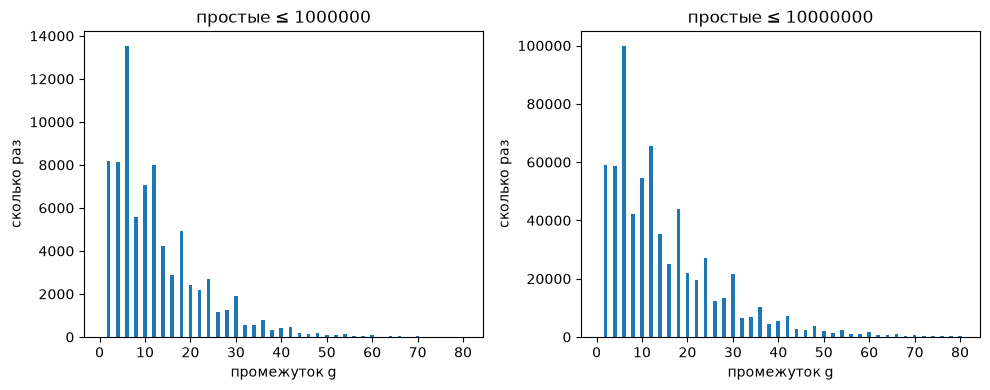

Самый частый промежуток — 6, и для миллиона, и для десяти миллионов.
Промежуток 2 встречается часто, но реже. Хвост длинных промежутков редкий.
При переходе к 10^7 распределение того же вида: мода не сдвигается с 6.


In [55]:
# Ваше решение:
# Промежутки g = p_{следующее} - p между простыми p <= N.
# Для 10^7 флаги лежат в bytearray, не в list.

from collections import Counter
from math import isqrt

import matplotlib.pyplot as plt


def sieve_primes(n):
    """Простые p <= n. Один байт на число."""
    if n < 2:
        return []
    flags = bytearray(b"\x01") * (n + 1)
    flags[0] = flags[1] = 0
    if n >= 4:
        flags[4::2] = bytes(len(flags[4::2]))
    p = 3
    limit = isqrt(n)
    while p <= limit:
        if flags[p]:
            start = p * p
            step = 2 * p
            block = flags[start::step]
            flags[start::step] = bytes(len(block))
        p += 2
    return [2] + [i for i in range(3, n + 1, 2) if flags[i]]


def prime_gaps(n):
    primes = sieve_primes(n)
    return [b - a for a, b in zip(primes, primes[1:])]


fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, limit in zip(axes, (10**6, 10**7)):
    gaps = prime_gaps(limit)
    counts = Counter(gaps)
    mode = max(counts, key=counts.get)
    print(
        f"p <= {limit}: промежутков {len(gaps)},"
        f" чаще всего g = {mode} ({counts[mode]} раз),"
        f" наибольший промежуток {max(gaps)}"
    )
    width = min(max(gaps), 80)
    ax.bar(range(1, width + 1), [counts[g] for g in range(1, width + 1)])
    ax.set_xlabel("промежуток g")
    ax.set_ylabel("сколько раз")
    ax.set_title(f"простые ≤ {limit}")
fig.tight_layout()
plt.show()

print(
    "Самый частый промежуток — 6, и для миллиона, и для десяти миллионов.\n"
    "Промежуток 2 встречается часто, но реже. Хвост длинных промежутков редкий.\n"
    "При переходе к 10^7 распределение того же вида: мода не сдвигается с 6."
)


Для диапазона до $10^6$ промежутки размера $2$ (простые-близнецы) встречаются более 8000 раз; близкое число раз встречается и промежуток размера $4$. Наиболее заметный пик возникает при размере $6$, а повышенные частоты наблюдаются также при значениях $12,18,24,30$.

Это наблюдение относится к конечному вычислительному диапазону и само по себе не является асимптотическим утверждением.

<div style="background-color: #201f1b; padding: 20px; border-radius: 10px; border-left: 4px solid #d39e00;">

### 🔬 Исследование. Абсолютные и нормированные промежутки между простыми числами

Для простых чисел, не превосходящих $10^6$, рассмотрите абсолютные промежутки

$$
g_n=p_{n+1}-p_n
$$

и нормированные промежутки

$$
\rho_n=\frac{g_n}{\ln p_n}.
$$

**Prediction.** До вычислений сформулируйте прогноз: будет ли пара простых, на которой достигается максимальный $g_n$, обязательно давать и максимальное значение $\rho_n$? Обоснуйте ответ.

**Run.**

1. Найдите максимальный абсолютный промежуток $g_n$ и пару последовательных простых чисел $(p_n,p_{n+1})$, между которыми он возникает.
2. Для этой пары вычислите $\rho_n=g_n/\ln p_n$.
3. Независимо найдите максимальное значение $\rho_n$ на том же диапазоне и соответствующую пару простых.
4. Постройте график $\rho_n$ как функции от $p_n$ или изобразите распределение значений $\rho_n$.
5. Повторите основные вычисления для $10^7$ и, если позволяет время вычислений и память, для $10^8$. Для $10^7$ и больше не используйте список `flags` типа `list` (см. задание 16): храните флаги в `bytearray` (1 байт на число) либо получите простые в SageMath через `prime_range`.

**Explain.** Сравните поведение $g_n$ и $\rho_n$. Объясните, зачем при сравнении промежутков, возникающих на существенно разных масштабах, делить $g_n$ на $\ln p_n$.

**Generalize.** Согласуются ли результаты с тем, что $\ln x$ задаёт средний масштаб промежутка около больших $x$? Почему конечный вычислительный эксперимент не доказывает утверждений об асимптотическом поведении максимальных или нормированных промежутков?

</div>


Простые до 10^6.
Максимальный g_n = 114 между 492113 и 492227
Для этой пары ρ_n = 8.6980
Максимальный ρ_n = 8.7350 между 370261 и 370373
Это одна и та же пара: False


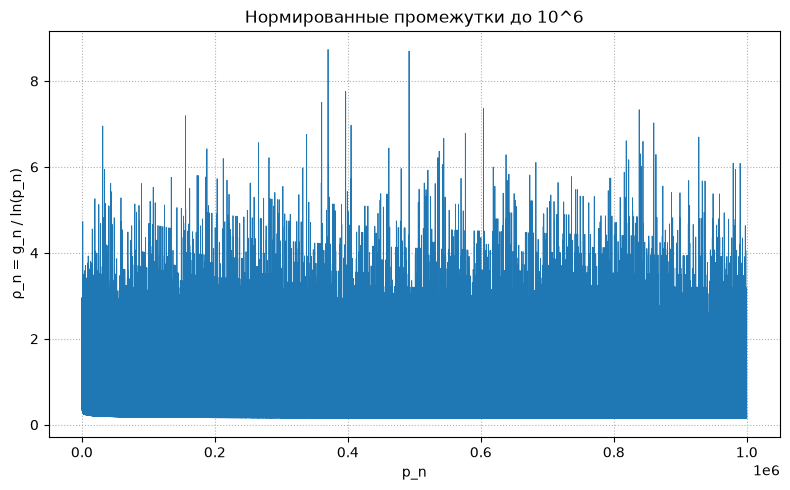

Простые до 10000000.
  max g_n = 154 между 4652353 и 4652507
  ρ на этой паре = 10.0307; max ρ_n = 10.1970 между 2010733 и 2010881
  одна и та же пара: False
Простые до 100000000.
  max g_n = 220 между 47326693 и 47326913
  ρ на этой паре = 12.4487; max ρ_n = 12.4615 между 20831323 и 20831533
  одна и та же пара: False
Объяснение. g_n измеряет промежуток в единицах, ρ_n — в единицах среднего
масштаба ln(p_n). По теореме о простых средний промежуток около x имеет
порядок ln(x), потому что π(x) ~ x/ln(x) и среднее расстояние x/π(x) ~ ln(x).
Деление на ln(p_n) позволяет сравнивать промежутки с разных масштабов:
абсолютный рекорд у большого простого может быть обычным для своего места,
а небольшой промежуток в начале — большим относительно ln(p).
Поэтому пара максимального g_n и пара максимального ρ_n не обязаны совпасть.
Конечный перебор до 10^6, 10^7 или 10^8 не доказывает, как растут
максимальные или нормированные промежутки при x → ∞.


In [56]:
# Выполните исследование здесь:
# Прогноз до вычислений. Пара с наибольшим g_n не обязана давать наибольшее ρ_n.
# ρ_n = g_n / ln(p_n), а ln(p_n) растёт. Крупный промежуток у большого простого
# может проиграть умеренному промежутку у меньшего простого, и наоборот.

import math

import matplotlib.pyplot as plt


def gap_records(n):
    primes = sieve_primes(n)
    best_g = (0, None, None)
    best_rho = (0, None, None)
    rhos = []
    places = []
    for left, right in zip(primes, primes[1:]):
        gap = right - left
        rho = gap / math.log(left)
        if gap > best_g[0]:
            best_g = (gap, left, right)
        if rho > best_rho[0]:
            best_rho = (rho, left, right)
        rhos.append(rho)
        places.append(left)
    return best_g, best_rho, places, rhos


print("Простые до 10^6.")
best_g, best_rho, places, rhos = gap_records(10**6)
g_gap, g_left, g_right = best_g
rho_on_max_g = g_gap / math.log(g_left)
print(f"Максимальный g_n = {g_gap} между {g_left} и {g_right}")
print(f"Для этой пары ρ_n = {rho_on_max_g:.4f}")
print(
    f"Максимальный ρ_n = {best_rho[0]:.4f}"
    f" между {best_rho[1]} и {best_rho[2]}"
)
print(f"Это одна и та же пара: {best_g[1:] == best_rho[1:]}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(places, rhos, linewidth=0.6)
ax.set_xlabel("p_n")
ax.set_ylabel("ρ_n = g_n / ln(p_n)")
ax.set_title("Нормированные промежутки до 10^6")
ax.grid(True, linestyle=":")
fig.tight_layout()
plt.show()

for limit in (10**7, 10**8):
    best_g, best_rho, _, _ = gap_records(limit)
    print(f"Простые до {limit}.")
    print(f"  max g_n = {best_g[0]} между {best_g[1]} и {best_g[2]}")
    print(
        f"  ρ на этой паре = {best_g[0] / math.log(best_g[1]):.4f};"
        f" max ρ_n = {best_rho[0]:.4f} между {best_rho[1]} и {best_rho[2]}"
    )
    print(f"  одна и та же пара: {best_g[1:] == best_rho[1:]}")

print(
    "Объяснение. g_n измеряет промежуток в единицах, ρ_n — в единицах среднего\n"
    "масштаба ln(p_n). По теореме о простых средний промежуток около x имеет\n"
    "порядок ln(x), потому что π(x) ~ x/ln(x) и среднее расстояние x/π(x) ~ ln(x).\n"
    "Деление на ln(p_n) позволяет сравнивать промежутки с разных масштабов:\n"
    "абсолютный рекорд у большого простого может быть обычным для своего места,\n"
    "а небольшой промежуток в начале — большим относительно ln(p).\n"
    "Поэтому пара максимального g_n и пара максимального ρ_n не обязаны совпасть.\n"
    "Конечный перебор до 10^6, 10^7 или 10^8 не доказывает, как растут\n"
    "максимальные или нормированные промежутки при x → ∞."
)


<div style="background-color: #1a1e20; padding: 20px; border-radius: 10px; border-left: 4px solid #007cba;">

### Задание 19

**«Заговор простых чисел»** (Prime Conspiracy).

Рассмотрим пару последовательных простых чисел. Пусть первое оканчивается цифрой $a$, а следующее за ним — цифрой $b$.
Например, пара $(3,7)$ означает, что за простым числом, оканчивающимся на 3, следует простое число, оканчивающееся на 7.

Для достаточно больших простых чисел возможны последние цифры 1, 3, 7 и 9. Если бы переходы между последними цифрами
соседних простых чисел были независимыми и равновероятными, каждая из 16 возможных пар
$(1,1),(1,3),(1,7),(1,9),\ldots,(9,9)$ встречалась бы примерно в $1/16=6.25\%$ случаев.

Исследуйте фактическое распределение этих пар среди простых чисел, не превосходящих одного миллиона.
Сравните полученные частоты с $6.25\%$ и опишите наблюдаемое отклонение от равномерного распределения.

</div>


In [57]:
# Ваше решение:
# После 5 последнее простое оканчивается на 1, 3, 7 или 9.
# Пары с 2 и 5 в таблицу из 16 клеток не входят: иных последних цифр
# у простых больше 5 не бывает.

from collections import Counter

primes = [p for p in prime_list if p > 5]
pairs = Counter((left % 10, right % 10) for left, right in zip(primes, primes[1:]))
total = sum(pairs.values())
digits = (1, 3, 7, 9)
uniform = 1 / 16

print(f"Пар среди простых 7 <= p <= 10^6: {total}")
print(f"Равномерная доля: {uniform:.2%}")
print(f"{'пара':>8} {'доля':>8} {'минус 6.25%':>12}")
for a in digits:
    for b in digits:
        share = pairs[(a, b)] / total
        print(f"{a}->{b:>2} {share:8.2%} {share - uniform:12.2%}")

repeat = sum(pairs[(d, d)] for d in digits) / total
change = 1 - repeat
print(f"Повтор последней цифры: {repeat:.2%}, смена: {change:.2%}")
print(
    "Равномерные 6.25% не получаются. Повтор той же последней цифры\n"
    "встречается реже четверти случаев, то есть реже, чем 4/16.\n"
    "Смена цифры, особенно на другую из {1, 3, 7, 9}, встречается чаще.\n"
    "Соседние простые до миллиона не ведут себя как независимый выбор\n"
    "последней цифры. Это описание одного конечного отрезка, не теорема\n"
    "о всех простых."
)


Пар среди простых 7 <= p <= 10^6: 78494
Равномерная доля: 6.25%
    пара     доля  минус 6.25%
1-> 1    4.09%       -2.16%
1-> 3    8.02%        1.77%
1-> 7    8.34%        2.09%
1-> 9    4.53%       -1.72%
3-> 1    5.59%       -0.66%
3-> 3    3.58%       -2.67%
3-> 7    7.41%        1.16%
3-> 9    8.47%        2.22%
7-> 1    6.46%        0.21%
7-> 3    6.93%        0.68%
7-> 7    3.66%       -2.59%
7-> 9    7.94%        1.69%
9-> 1    8.85%        2.60%
9-> 3    6.51%        0.26%
9-> 7    5.58%       -0.67%
9-> 9    4.02%       -2.23%
Повтор последней цифры: 15.35%, смена: 84.65%
Равномерные 6.25% не получаются. Повтор той же последней цифры
встречается реже четверти случаев, то есть реже, чем 4/16.
Смена цифры, особенно на другую из {1, 3, 7, 9}, встречается чаще.
Соседние простые до миллиона не ведут себя как независимый выбор
последней цифры. Это описание одного конечного отрезка, не теорема
о всех простых.


# Литература

1. Крэндалл Р., Померанс К. *Простые числа. Криптографические и вычислительные аспекты* : пер. с англ. — 2011. — 664 с.
2. Weissman M. H. *An Illustrated Theory of Numbers*. — Providence, RI : American Mathematical Society, 2017. — XV, 323 p. — (Miscellaneous Books ; vol. 105). — ISBN 978-1-4704-3493-9.
3. [Prime Conspiracy](https://www.quantamagazine.org/mathematicians-discover-prime-conspiracy-20160313).
4. Shoup V. *A Computational Introduction to Number Theory and Algebra*. — 2nd ed. — Cambridge : Cambridge University Press, 2009.
5. Cohen H. *A Course in Computational Algebraic Number Theory*. — Berlin ; Heidelberg : Springer-Verlag, 1993. — (Graduate Texts in Mathematics ; vol. 138).
6. Menezes A. J., van Oorschot P. C., Vanstone S. A. *Handbook of Applied Cryptography*. — Boca Raton : CRC Press, 1996.
7. Hoffstein J., Pipher J., Silverman J. H. *An Introduction to Mathematical Cryptography*. — 2nd ed. — New York : Springer, 2014. — (Undergraduate Texts in Mathematics).
8. Богопольский О. В. *Алгоритмическая теория чисел и элементы криптографии* : спецкурс НГУ. — Новосибирск, 2005.
9. [SageMath Reference Manual: Elementary Number Theory](https://doc.sagemath.org/html/en/reference/rings_standard/).
10. [SageMathCell](https://sagecell.sagemath.org/) — онлайн-среда для выполнения небольших вычислений в SageMath.
11. Zhang Y. *Bounded Gaps Between Primes*. — Annals of Mathematics. — 2014. — Vol. 179, No. 3. — P. 1121–1174. — [DOI](https://doi.org/10.4007/annals.2014.179.3.7).
12. Maynard J. *Small Gaps Between Primes*. — Annals of Mathematics. — 2015. — Vol. 181, No. 1. — P. 383–413. — [DOI](https://doi.org/10.4007/annals.2015.181.1.7).
13. Granville A., Martin G. *Prime Number Races*. — The American Mathematical Monthly. — 2006. — Vol. 113, No. 1. — P. 1–33. — [arXiv](https://arxiv.org/abs/math/0408319).
14. Rubinstein M., Sarnak P. *Chebyshev's Bias*. — Experimental Mathematics. — 1994. — Vol. 3, No. 3. — P. 173–197. — [DOI](https://doi.org/10.1080/10586458.1994.10504289).
